In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, max_error
from tabulate import tabulate
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MaxAbsScaler
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import yeojohnson, boxcox

In [3]:
restaurants_df = pd.read_csv("../Foursquare/final_restaurants_dataset_cleaned.csv")
coffeeshops_df = pd.read_csv("../Foursquare/final_coffeeshops_dataset_cleaned.csv")
print(restaurants_df.info())
print(coffeeshops_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1221 entries, 0 to 1220
Data columns (total 36 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Business ID                               1221 non-null   object 
 1   Name                                      1221 non-null   object 
 2   Latitude                                  1221 non-null   float64
 3   Longitude                                 1221 non-null   float64
 4   Category                                  1221 non-null   object 
 5   Rating                                    1221 non-null   object 
 6   Popularity                                1221 non-null   float64
 7   Google Place ID                           1221 non-null   object 
 8   Business Status                           1221 non-null   object 
 9   Distance (m)                              1221 non-null   float64
 10  Cluster                             

## Data Pre-processing

In [4]:
combined_df = pd.concat([coffeeshops_df, restaurants_df], ignore_index=True)
combined_df["generalCategory"] = combined_df["generalCategory"].map({"coffee shop": 0, "restaurant": 1})

In [5]:
# Drop irrelevant columns
drop_columns = ['Business ID', 'Latitude'	, 'Longitude', 'Name', 'Category', 'Rating', 'Google Place ID', 'Business Status',
                'Cluster', 'Distance (m)', 'Avg Rating - Business Type', 'Competition - Business Type/Area', 'Competition - Food & Dining/Area',
                'Competition - Business Type/POI Density', 'Competition - Food & Dining/POI Densit', 'Competition - Business Type/related POIs'
               ,'Competition - Food & Dining/POI Density']
combined_df.drop(columns=drop_columns, inplace=True, errors='ignore')

In [6]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1910 entries, 0 to 1909
Data columns (total 20 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Popularity                                1910 non-null   float64
 1   generalCategory                           1910 non-null   int64  
 2   Religious Institutions                    1910 non-null   int64  
 3   Coffee Shops                              1910 non-null   int64  
 4   Food & Dining                             1910 non-null   int64  
 5   Restaurants                               1910 non-null   int64  
 6   Home & Construction Services              1910 non-null   int64  
 7   Entertainment & Recreation                1910 non-null   int64  
 8   Retail & Shopping                         1910 non-null   int64  
 9   Finance & Services                        1910 non-null   int64  
 10  Education                           

In [7]:
combined_df.fillna(combined_df.median(numeric_only=True), inplace=True)
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1910 entries, 0 to 1909
Data columns (total 20 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Popularity                                1910 non-null   float64
 1   generalCategory                           1910 non-null   int64  
 2   Religious Institutions                    1910 non-null   int64  
 3   Coffee Shops                              1910 non-null   int64  
 4   Food & Dining                             1910 non-null   int64  
 5   Restaurants                               1910 non-null   int64  
 6   Home & Construction Services              1910 non-null   int64  
 7   Entertainment & Recreation                1910 non-null   int64  
 8   Retail & Shopping                         1910 non-null   int64  
 9   Finance & Services                        1910 non-null   int64  
 10  Education                           

In [8]:
# Check for Missing Values
print("\nMissing Values Per Column:")
print(combined_df.isnull().sum())
print("\nTotal Missing Values:", combined_df.isnull().sum().sum())


Missing Values Per Column:
Popularity                                  0
generalCategory                             0
Religious Institutions                      0
Coffee Shops                                0
Food & Dining                               0
Restaurants                                 0
Home & Construction Services                0
Entertainment & Recreation                  0
Retail & Shopping                           0
Finance & Services                          0
Education                                   0
Health                                      0
Public & Government Services                0
Hotels & Hospitality                        0
Transportation & Travel                     0
Beauty & Wellness                           0
POI Density                                 0
Avg Rating - Food & Dining                  0
Competition - Food & Dining/related POIs    0
Population Within 1km                       0
dtype: int64

Total Missing Values: 0


In [26]:
# Helper Functions to remove outliers and highly correlated features

def remove_outliers(X, y):
    """Remove outliers using IQR."""
    Q1 = np.percentile(y, 25)
    Q3 = np.percentile(y, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = (y >= lower_bound) & (y <= upper_bound)
    return X[mask], y[mask]

    
# Remove Highly Correlated Features (Modified)
removed_corr_features = []  # List to store removed features

def remove_highly_correlated_features(X, threshold=0.95):
    """Removes highly correlated features from X."""
    corr_matrix = X.corr().abs()  # Compute absolute correlation matrix
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  # Upper triangle

    # Find columns to drop
    to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]
    return X.drop(columns=to_drop, errors='ignore'), to_drop  # Drop and return removed features

In [9]:
combined_df

,Popularity,generalCategory,Religious Institutions,Coffee Shops,Food & Dining,Restaurants,Home & Construction Services,Entertainment & Recreation,Retail & Shopping,Finance & Services,Education,Health,Public & Government Services,Hotels & Hospitality,Transportation & Travel,Beauty & Wellness,POI Density,Avg Rating - Food & Dining,Competition - Food & Dining/related POIs,Population Within 1km
0,0.968299,0,1,2,2,1,0,0,5,0,0,0,0,0,14,1,58,4.200000,0.285714,2120
1,0.991283,0,1,2,9,8,0,3,4,2,0,0,0,0,3,1,56,4.100000,0.562500,10498
2,0.963778,0,3,1,4,3,0,0,3,2,2,0,1,0,3,1,57,4.200000,0.571429,12828
3,0.943726,0,1,1,14,13,0,0,18,4,0,2,0,3,1,6,58,3.992857,0.400000,56606
4,0.544394,0,2,3,16,13,0,0,8,6,0,2,0,7,2,5,58,3.975000,0.516129,72642
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1905,0.997484,1,1,4,16,11,0,2,39,0,1,2,0,0,0,0,58,3.956250,0.280702,18538
1906,0.965308,1,0,3,14,10,0,0,21,5,1,3,1,3,0,2,58,4.000000,0.368421,30218
1907,0.725694,1,0,3,16,13,0,1,4,4,2,1,2,1,2,4,58,3.471429,0.727273,1702
1908,0.884345,1,2,2,8,6,0,3,9,3,1,3,1,2,4,1,59,4.242857,0.363636,11467


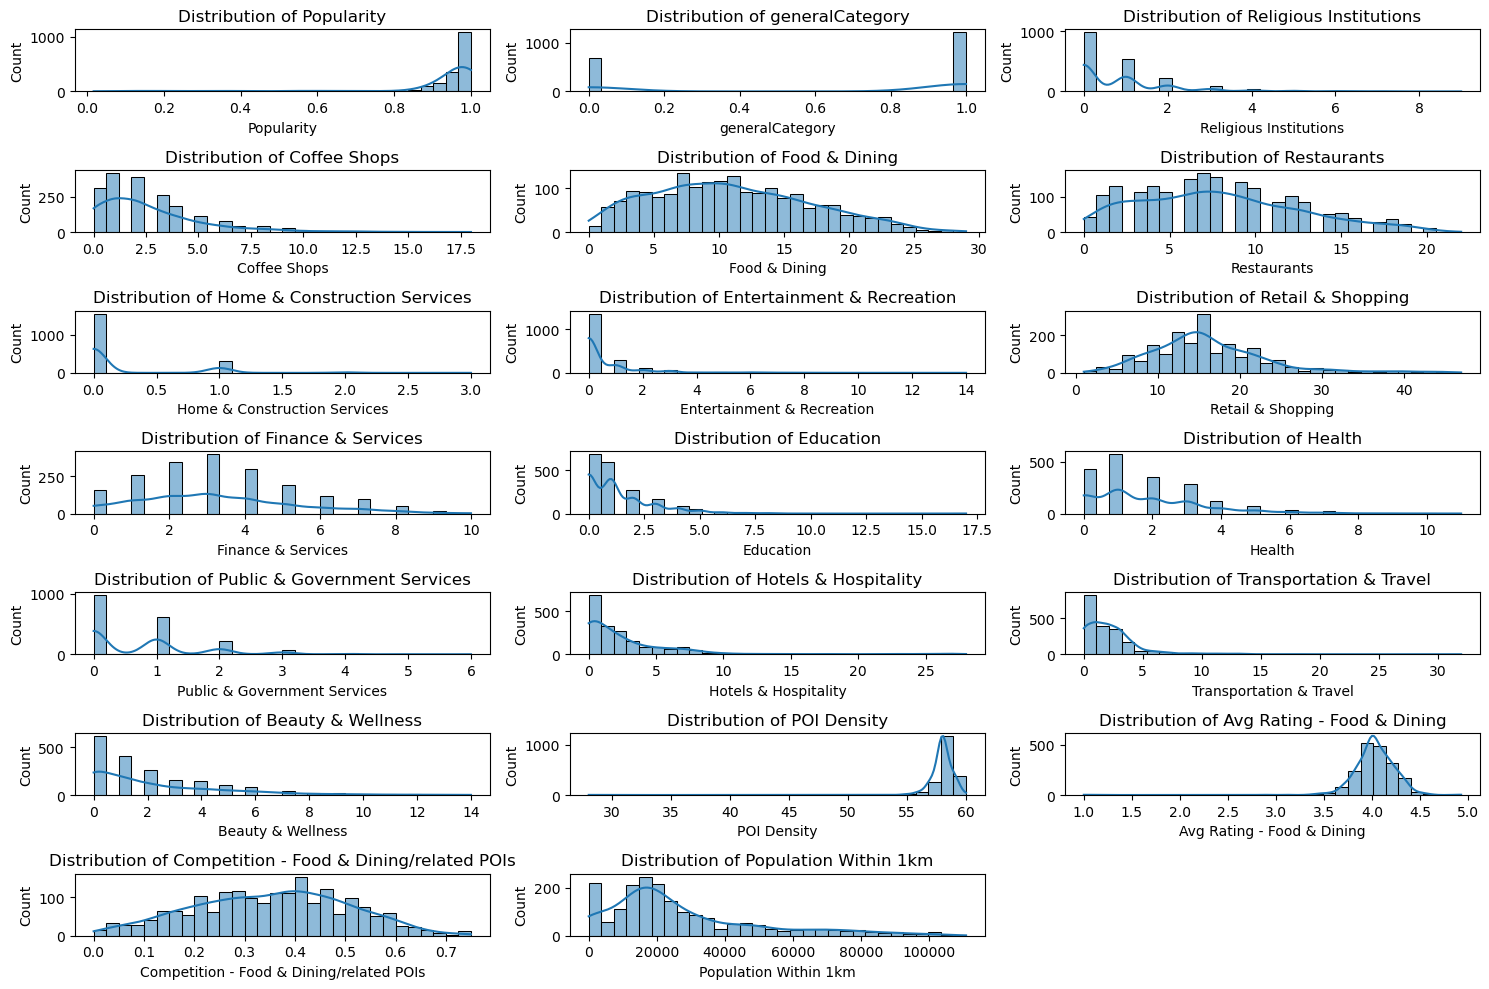

In [10]:
def plot_feature_distributions(df):
    num_cols = df.select_dtypes(include=['number']).columns 
    
    plt.figure(figsize=(15, 10))
    
    for i, col in enumerate(num_cols, 1):
        plt.subplot((len(num_cols) // 3) + 1, 3, i)  # Create subplots with 3 columns
        sns.histplot(df[col], kde=True, bins=30)  # Histogram with KDE
        plt.title(f'Distribution of {col}')
    
    plt.tight_layout()
    plt.show()

plot_feature_distributions(combined_df)


<class 'pandas.core.frame.DataFrame'>
Index: 1709 entries, 0 to 1909
Data columns (total 20 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Popularity                                1709 non-null   float64
 1   generalCategory                           1709 non-null   int64  
 2   Religious Institutions                    1709 non-null   int64  
 3   Coffee Shops                              1709 non-null   int64  
 4   Food & Dining                             1709 non-null   int64  
 5   Restaurants                               1709 non-null   int64  
 6   Home & Construction Services              1709 non-null   int64  
 7   Entertainment & Recreation                1709 non-null   int64  
 8   Retail & Shopping                         1709 non-null   int64  
 9   Finance & Services                        1709 non-null   int64  
 10  Education                                

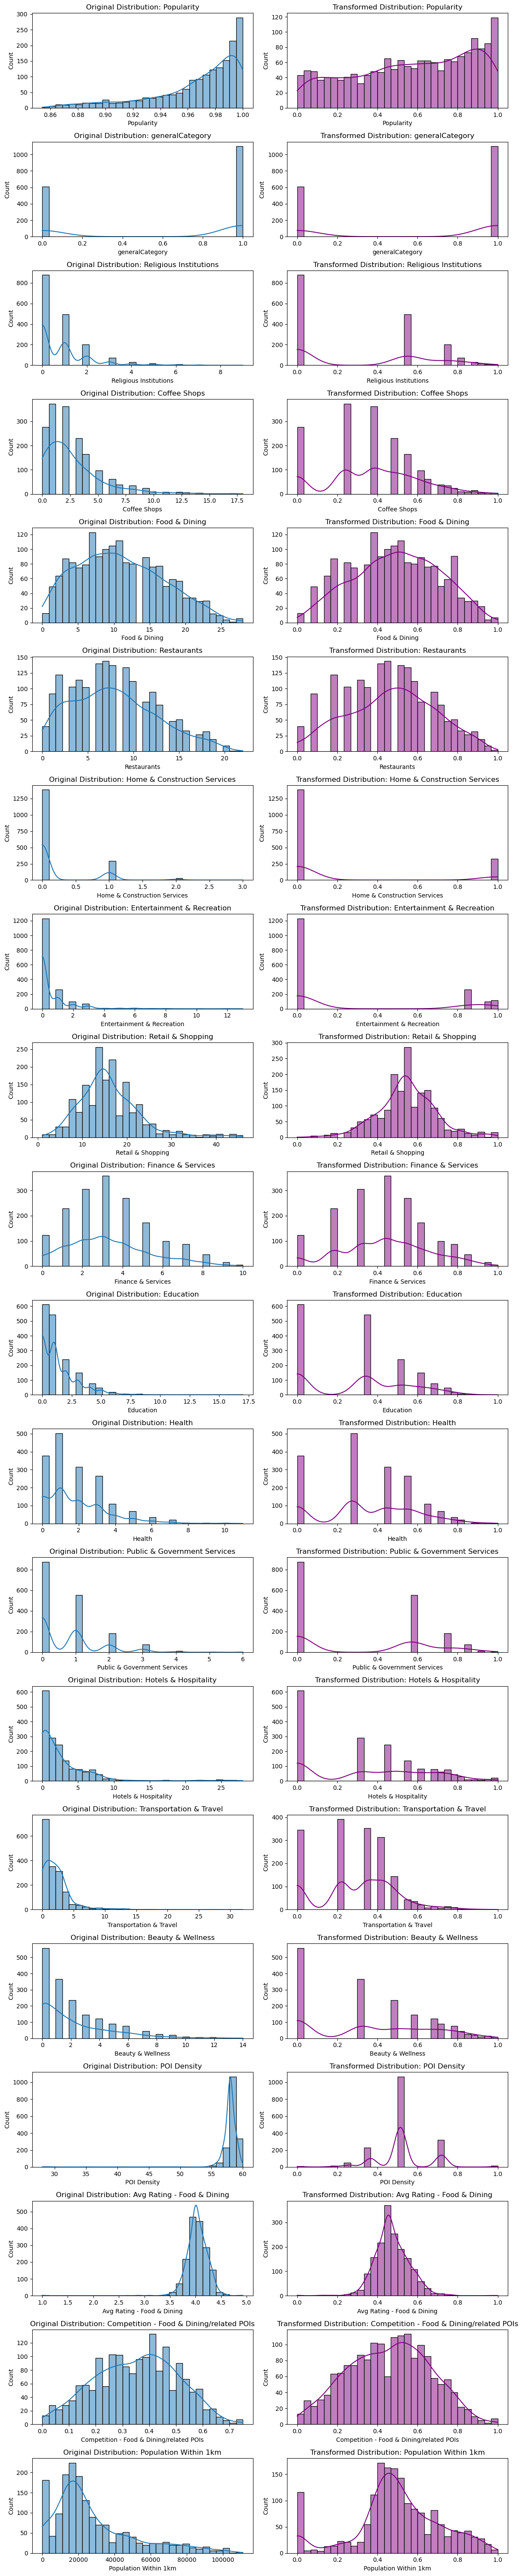


Shapiro-Wilk Normality Test Results:
                                         Shapiro-Wilk Test Statistic p-value  \
Popularity                                                  0.941258     0.0   
generalCategory                                             0.605886     0.0   
Religious Institutions                                      0.760322     0.0   
Coffee Shops                                                0.948158     0.0   
Food & Dining                                               0.986557     0.0   
Restaurants                                                  0.98381     0.0   
Home & Construction Services                                0.479157     0.0   
Entertainment & Recreation                                  0.584778     0.0   
Retail & Shopping                                           0.985463     0.0   
Finance & Services                                          0.967702     0.0   
Education                                                   0.859348     0.0   
He

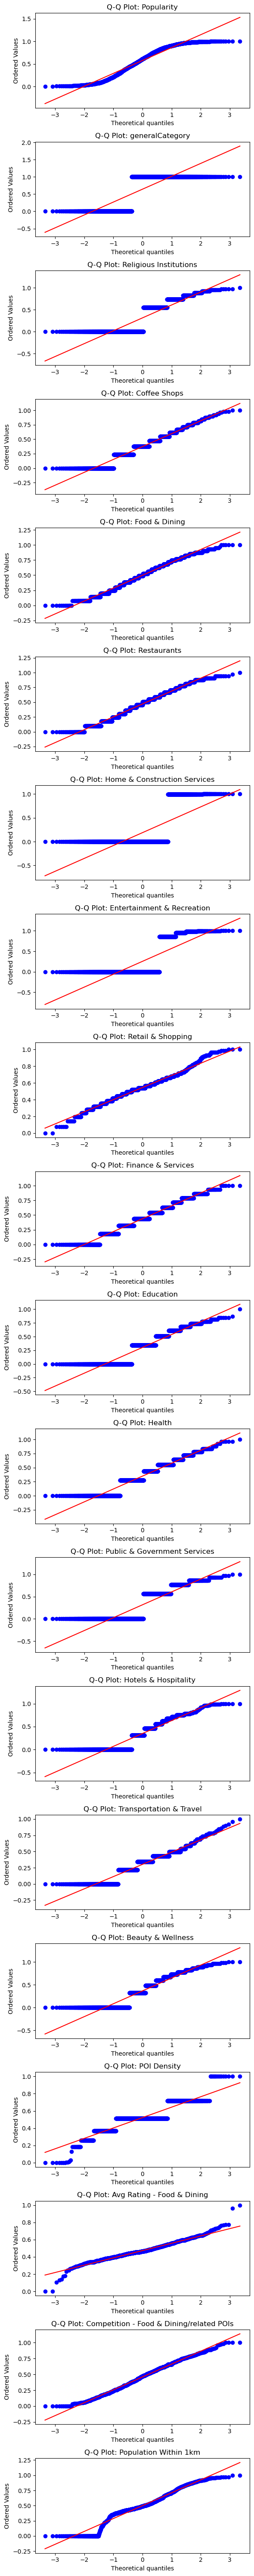

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import shapiro, probplot
from sklearn.preprocessing import PowerTransformer, MinMaxScaler

# Copy DataFrame
transformed_df = combined_df.copy()

# Remove outliers in 'Popularity' using IQR method
Q1 = transformed_df['Popularity'].quantile(0.25)
Q3 = transformed_df['Popularity'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
transformed_df = transformed_df[(transformed_df['Popularity'] >= lower_bound) & (transformed_df['Popularity'] <= upper_bound)]

transformed_df.info()
# Select numerical columns
num_cols = transformed_df.select_dtypes(include=['number']).columns

# Store original distributions before transformation
original_distributions = transformed_df[num_cols].copy()

# Apply PowerTransformer (normalize distribution)
power_transformer = PowerTransformer()
transformed_df[num_cols] = power_transformer.fit_transform(transformed_df[num_cols])

# Apply MinMaxScaler (scale to 0-1)
minmax_scaler = MinMaxScaler()
transformed_df[num_cols] = minmax_scaler.fit_transform(transformed_df[num_cols])

# Plot before and after transformation distributions
fig, axes = plt.subplots(nrows=len(num_cols), ncols=2, figsize=(12, len(num_cols) * 3))

for i, col in enumerate(num_cols):
    # Original distribution
    sns.histplot(original_distributions[col], kde=True, bins=30, ax=axes[i, 0])
    axes[i, 0].set_title(f'Original Distribution: {col}')
    
    # Transformed distribution
    sns.histplot(transformed_df[col], kde=True, bins=30, ax=axes[i, 1], color='purple')
    axes[i, 1].set_title(f'Transformed Distribution: {col}')

plt.tight_layout()
plt.show()

# Perform Shapiro-Wilk test for normality on each transformed feature
normality_results = {}
for col in num_cols:
    shapiro_test_stat, shapiro_p_value = shapiro(transformed_df[col])
    normality_results[col] = {
        "Shapiro-Wilk Test Statistic": shapiro_test_stat,
        "p-value": shapiro_p_value,
        "Normality": "Yes" if shapiro_p_value > 0.05 else "No"
    }

# Convert results to DataFrame
normality_df = pd.DataFrame(normality_results).T

# Display normality test results
print("\nShapiro-Wilk Normality Test Results:")
print(normality_df)

# Q-Q Plots for each transformed feature
fig, axes = plt.subplots(nrows=len(num_cols), figsize=(6, len(num_cols) * 3))

for i, col in enumerate(num_cols):
    probplot(transformed_df[col], dist="norm", plot=axes[i])
    axes[i].set_title(f"Q-Q Plot: {col}")

plt.tight_layout()
plt.show()


In [12]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Define columns to exclude from scaling
exclude_columns = ['generalCategory', 'Popularity', 'Competition - Food & Dining/related POIs']

# Select only numeric columns EXCEPT the excluded columns
numeric_features = combined_df.drop(columns=exclude_columns)

# Apply MinMax Scaling only to selected columns
scaler = MinMaxScaler()
scaled_features = pd.DataFrame(scaler.fit_transform(numeric_features), columns=numeric_features.columns)

# Add back the excluded columns (ensure it's only added once)
df_scaled = pd.concat([scaled_features, combined_df[exclude_columns].reset_index(drop=True)], axis=1)

# Identify the last column after merging
last_column = df_scaled.columns[-1]

# Define the new column order, ensuring "Competition" appears only once before the last column
column_order = (
    ['Popularity', 'generalCategory'] + 
    [col for col in df_scaled.columns if col not in ['Popularity', 'generalCategory', 'Competition - Food & Dining/related POIs', last_column]] + 
    (['Competition - Food & Dining/related POIs'] if 'Competition - Food & Dining/related POIs' in df_scaled.columns else []) + 
    [last_column]
)

# Ensure "Competition - Food & Dining/related POIs" is removed if it's the last column duplicate
if column_order[-2] == column_order[-1]:
    column_order.pop(-2)

# Reorder DataFrame
df_scaled = df_scaled[column_order]
df_scaled
# Display the corrected DataFrame
#import ace_tools as tools
#tools.display_dataframe_to_user(name="Corrected Scaled DataFrame", dataframe=df_scaled)


,Popularity,generalCategory,Religious Institutions,Coffee Shops,Food & Dining,Restaurants,Home & Construction Services,Entertainment & Recreation,Retail & Shopping,Finance & Services,Education,Health,Public & Government Services,Hotels & Hospitality,Transportation & Travel,Beauty & Wellness,POI Density,Avg Rating - Food & Dining,Population Within 1km,Competition - Food & Dining/related POIs
0,0.968299,0,0.111111,0.111111,0.068966,0.045455,0.0,0.000000,0.086957,0.0,0.000000,0.000000,0.000000,0.000000,0.43750,0.071429,0.93750,0.815287,0.019100,0.285714
1,0.991283,0,0.111111,0.111111,0.310345,0.363636,0.0,0.214286,0.065217,0.2,0.000000,0.000000,0.000000,0.000000,0.09375,0.071429,0.87500,0.789809,0.094583,0.562500
2,0.963778,0,0.333333,0.055556,0.137931,0.136364,0.0,0.000000,0.043478,0.2,0.117647,0.000000,0.166667,0.000000,0.09375,0.071429,0.90625,0.815287,0.115575,0.571429
3,0.943726,0,0.111111,0.055556,0.482759,0.590909,0.0,0.000000,0.369565,0.4,0.000000,0.181818,0.000000,0.107143,0.03125,0.428571,0.93750,0.762511,0.509996,0.400000
4,0.544394,0,0.222222,0.166667,0.551724,0.590909,0.0,0.000000,0.152174,0.6,0.000000,0.181818,0.000000,0.250000,0.06250,0.357143,0.93750,0.757962,0.654474,0.516129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1905,0.997484,1,0.111111,0.222222,0.551724,0.500000,0.0,0.142857,0.826087,0.0,0.058824,0.181818,0.000000,0.000000,0.00000,0.000000,0.93750,0.753185,0.167020,0.280702
1906,0.965308,1,0.000000,0.166667,0.482759,0.454545,0.0,0.000000,0.434783,0.5,0.058824,0.272727,0.166667,0.107143,0.00000,0.142857,0.93750,0.764331,0.272251,0.368421
1907,0.725694,1,0.000000,0.166667,0.551724,0.590909,0.0,0.071429,0.065217,0.4,0.117647,0.090909,0.333333,0.035714,0.06250,0.285714,0.93750,0.629663,0.015334,0.727273
1908,0.884345,1,0.222222,0.111111,0.275862,0.272727,0.0,0.214286,0.173913,0.3,0.058824,0.272727,0.166667,0.071429,0.12500,0.071429,0.96875,0.826206,0.103313,0.363636


## Feature Analysis

Correlation - NOT TRANSFORMED

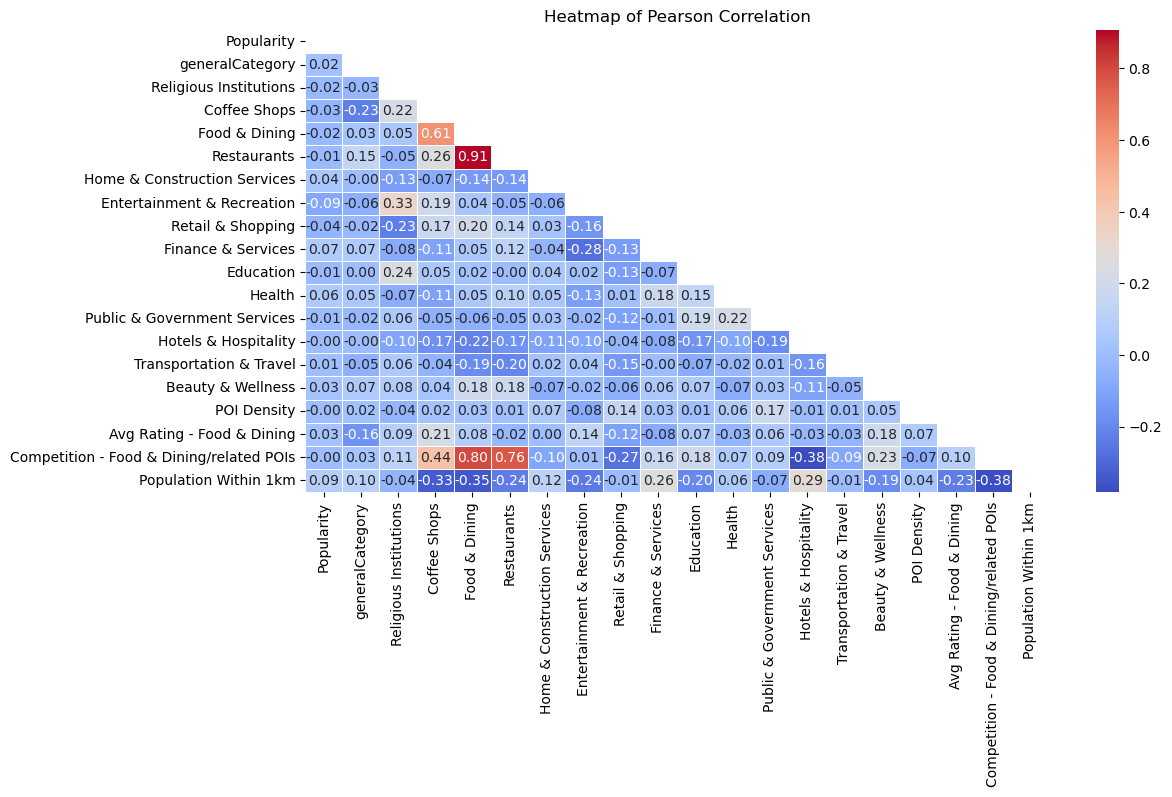

In [ ]:
# Compute Pearson correlation
corr_matrix = combined_df.corr()

# Create a mask for the upper triangular part
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Heatmap of Pearson Correlation")
plt.show()

Correlation - TRANSFORMED

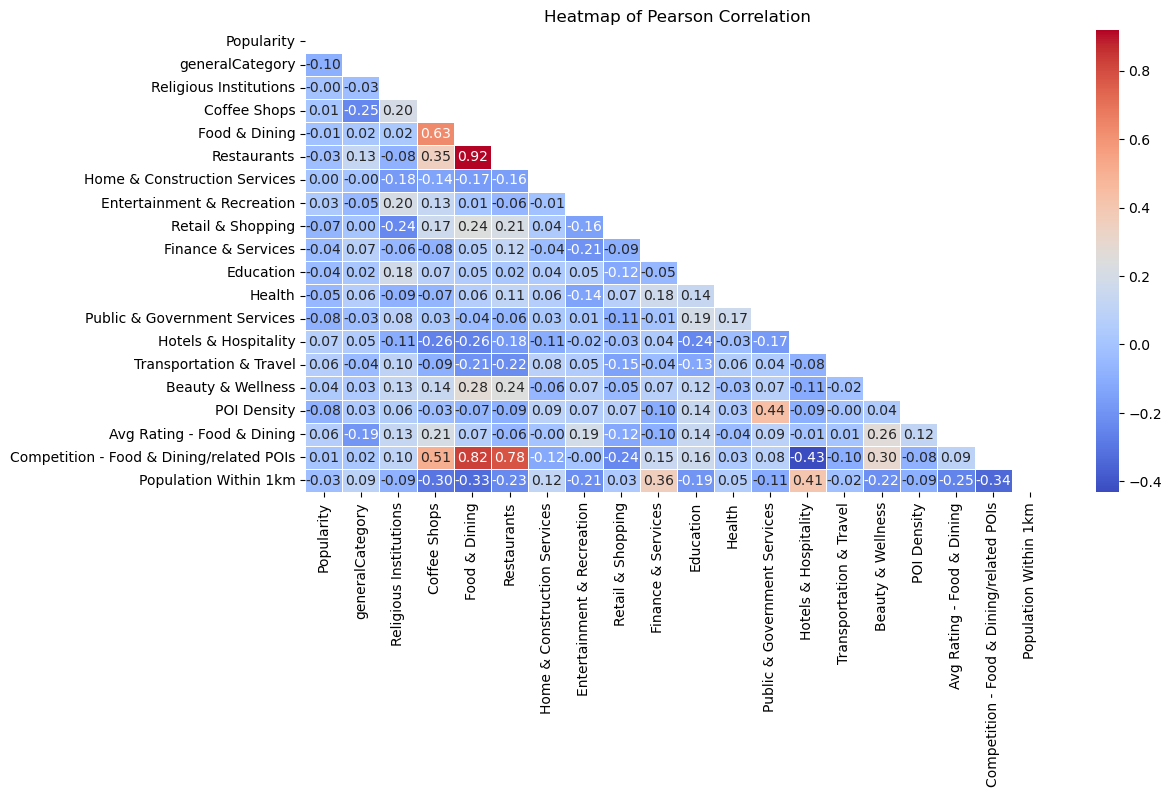

In [14]:
# Compute Pearson correlation for scaled data
corr_matrix = transformed_df.corr()

# Create a mask for the upper triangular part
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Heatmap of Pearson Correlation")
plt.show()

### Scatterplots (individual feature vs target) - NOT TRANSFORMED

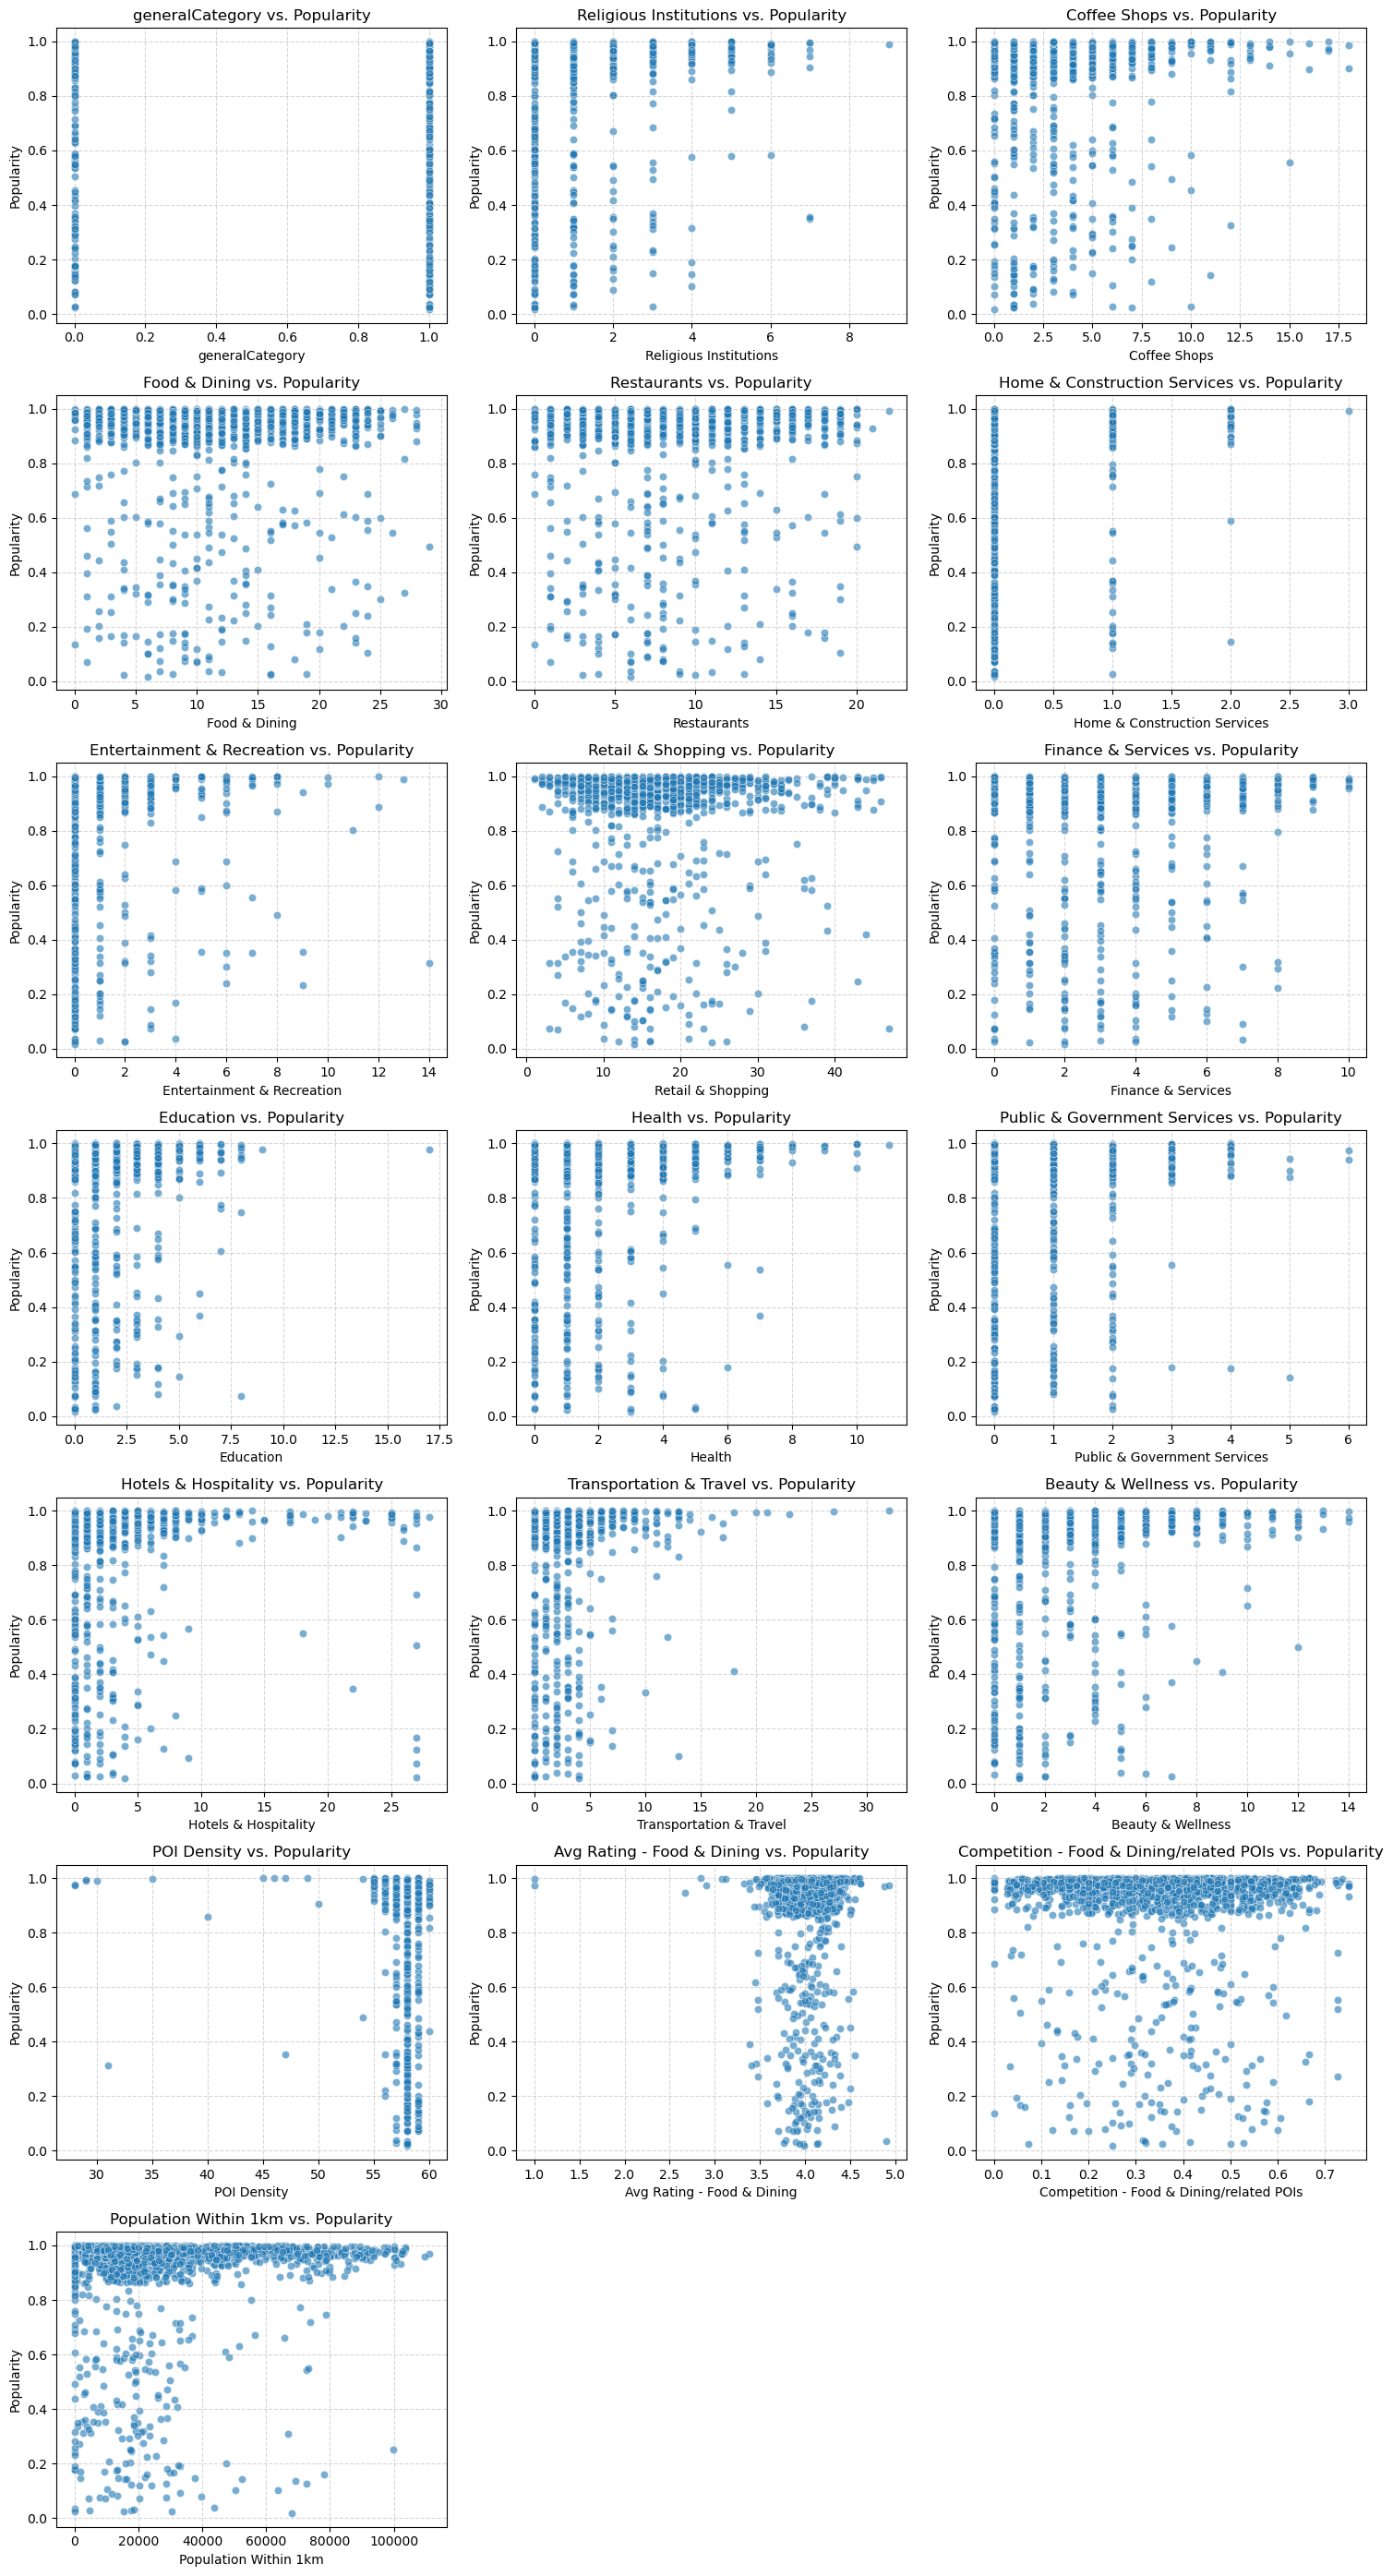

In [15]:
# Original Dataframe (WITHOUT transformation)
# Filter only numeric features (excluding target variable "Popularity")
numeric_features = combined_df.select_dtypes(include=np.number).columns
features_to_plot = [feature for feature in numeric_features if feature != "Popularity"]

# Define grid size
num_features = len(features_to_plot)
num_cols = 3  # Number of columns in the grid
num_rows = (num_features // num_cols) + (num_features % num_cols > 0)  # Compute required rows

# Create subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 4))
axes = axes.flatten()  # Flatten the 2D array of axes for easy indexing

# Loop through features and create scatter plots
for i, feature in enumerate(features_to_plot):
    sns.scatterplot(x=combined_df[feature], y=combined_df["Popularity"], alpha=0.6, ax=axes[i])
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel("Popularity", fontsize=10)
    axes[i].set_title(f"{feature} vs. Popularity", fontsize=12)
    axes[i].grid(True, linestyle="--", alpha=0.5)

# Remove empty subplots if num_features < num_cols*num_rows
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])  # Remove unused subplots

# Adjust layout
plt.tight_layout()
plt.show()


### Scatterplots (individual feature vs target) - TRANSFORMED

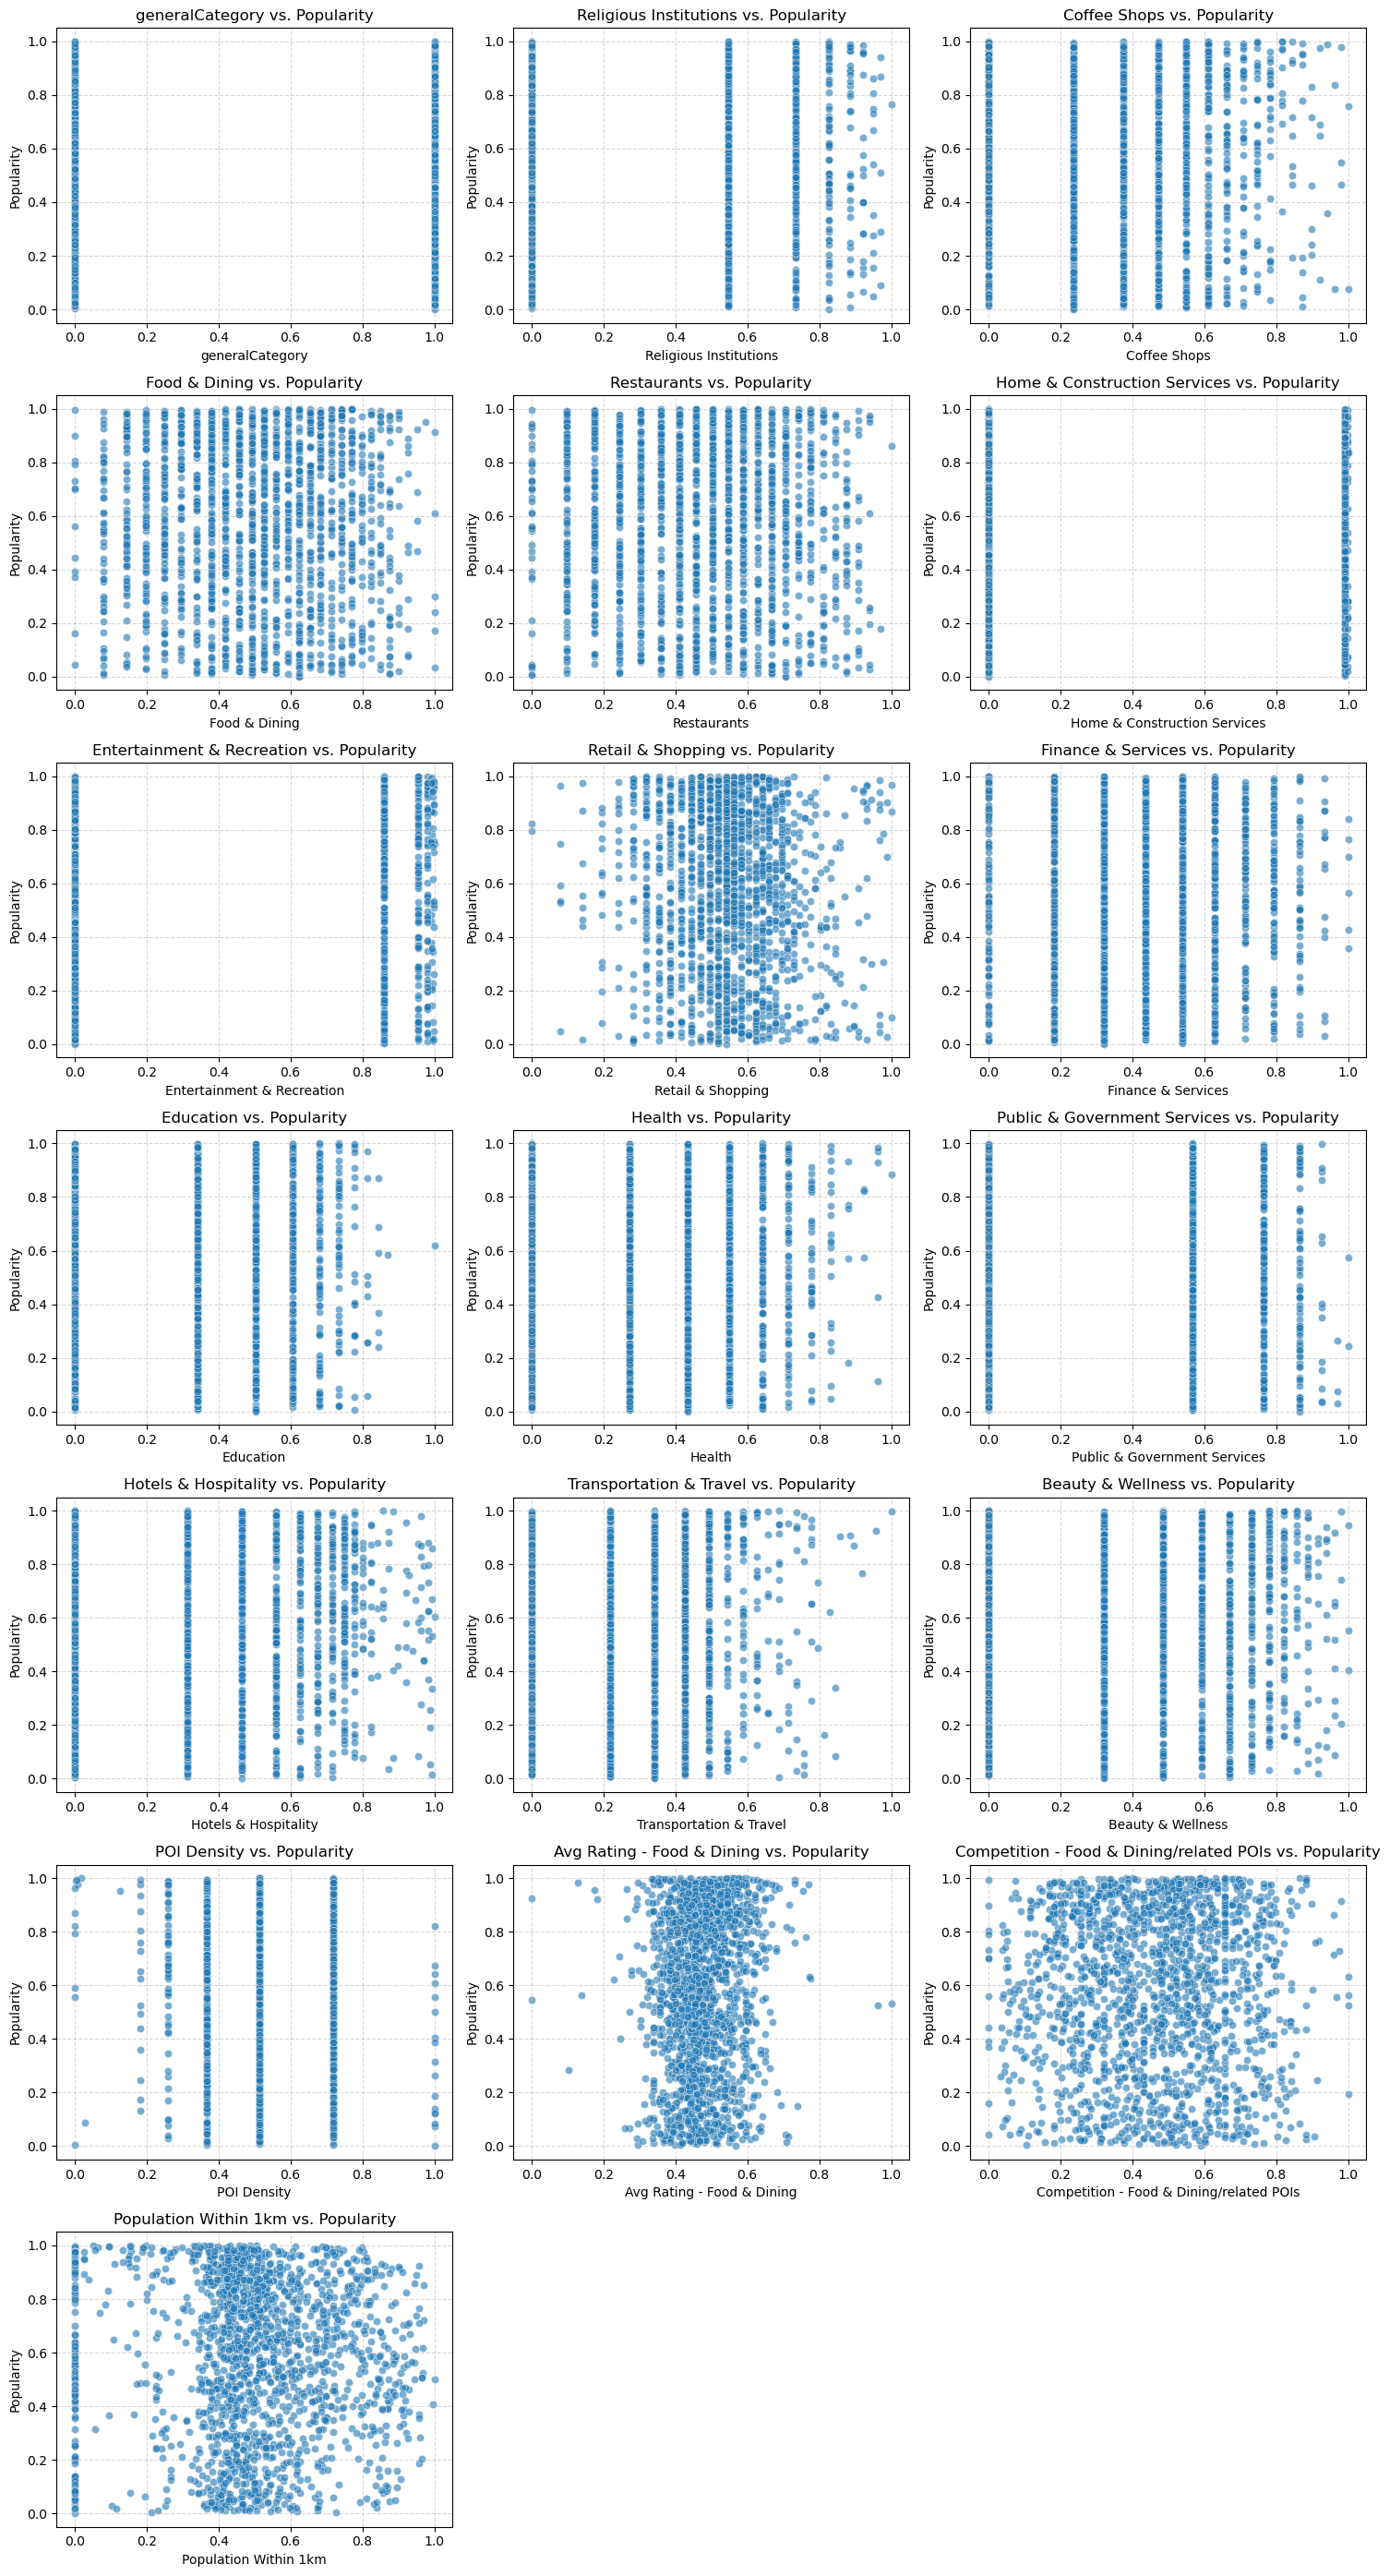

In [16]:
#Scatterplots of Transformed Data
# Filter only numeric features (excluding target variable "Popularity") for transformed data
numeric_features = transformed_df.select_dtypes(include=np.number).columns
features_to_plot = [feature for feature in numeric_features if feature != "Popularity"]

# Define grid size
num_features = len(features_to_plot)
num_cols = 3  # Number of columns in the grid
num_rows = (num_features // num_cols) + (num_features % num_cols > 0)  # Compute required rows

# Create subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 4))
axes = axes.flatten()  # Flatten the 2D array of axes for easy indexing

# Loop through features and create scatter plots
for i, feature in enumerate(features_to_plot):
    sns.scatterplot(x=transformed_df[feature], y=transformed_df["Popularity"], alpha=0.6, ax=axes[i])
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel("Popularity", fontsize=10)
    axes[i].set_title(f"{feature} vs. Popularity", fontsize=12)
    axes[i].grid(True, linestyle="--", alpha=0.5)

# Remove empty subplots if num_features < num_cols*num_rows
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])  # Remove unused subplots

# Adjust layout
plt.tight_layout()
plt.show()


# Model Training w/ Manual Grid Search

## LSTM - EXP 1

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, PowerTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, max_error, median_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from itertools import product

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Function to create sequences for LSTM
def create_sequences(data, target, seq_length=20):
    X_seq, y_seq = [], []
    for i in range(len(data) - seq_length):
        X_seq.append(data[i:i + seq_length])
        y_seq.append(target[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

# Grid search function
def grid_search_lstm(df):
    X = df
    y = df["Popularity"]

    # Remove outliers
    X, y = remove_outliers(X, y)
    X, removed_corr_features = remove_highly_correlated_features(X, threshold=0.9)
    print(f"Removed highly correlated features: {removed_corr_features}")
    
    # Split dataset (80% train, 20% test) BEFORE applying transformations
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Apply PowerTransformer (normalize distribution) on training set only
    num_cols = X.select_dtypes(include=['number']).columns
    power_transformer = PowerTransformer()
    
    X_train[num_cols] = power_transformer.fit_transform(X_train[num_cols])
    X_test[num_cols] = power_transformer.transform(X_test[num_cols])  # Apply same transformation

    # Normalize features using MinMaxScaler (on numerical columns only)
    feature_scaler = MinMaxScaler()
    X_train[num_cols] = feature_scaler.fit_transform(X_train[num_cols])
    X_test[num_cols] = feature_scaler.transform(X_test[num_cols])

    # Normalize the target variable separately
    target_scaler = MinMaxScaler()
    y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
    y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

    # Sequence length
    sequence_length = 20

    # Create sequences for LSTM
    X_train_seq, y_train_seq = create_sequences(X_train.values, y_train_scaled, sequence_length)
    X_test_seq, y_test_seq = create_sequences(X_test.values, y_test_scaled, sequence_length)

    # Reshape input to match LSTM expectations
    X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], sequence_length, X_train.shape[1]))
    X_test_seq = X_test_seq.reshape((X_test_seq.shape[0], sequence_length, X_train.shape[1]))

    # Define hyperparameters for grid search
    lstm_units = [32, 64, 128]
    dropout_rates = [0.2, 0.3, 0.4]
    learning_rates = [0.001, 0.0005, 0.0001]
    batch_sizes = [16, 32, 64]

    best_model = None
    best_loss = float('inf')
    best_params = {}

    # Perform grid search
    for units, dropout, lr, batch_size in product(lstm_units, dropout_rates, learning_rates, batch_sizes):
        print(f"Training model with LSTM Units: {units}, Dropout: {dropout}, LR: {lr}, Batch Size: {batch_size}")
        
        # Build LSTM model
        model = Sequential([
            Bidirectional(LSTM(units, return_sequences=True, input_shape=(sequence_length, X_train.shape[1]))),
            Dropout(dropout),
            LSTM(units // 2, return_sequences=False),
            Dropout(dropout),
            Dense(units, activation='relu'),
            Dense(units // 2, activation='relu'),
            Dense(1)
        ])

        # Compile model
        model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics=['mae'])

        # Callbacks
        early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

        # Train model
        history = model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=batch_size, validation_data=(X_test_seq, y_test_seq),
                            verbose=0, callbacks=[early_stop, lr_scheduler])

        # Get best validation loss
        val_loss = min(history.history['val_loss'])
        
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = model
            best_params = {'LSTM Units': units, 'Dropout': dropout, 'Learning Rate': lr, 'Batch Size': batch_size}

    print("\n✅ Best Model Found!")
    print(best_params)

    # Make predictions with the best model
    y_pred = best_model.predict(X_test_seq)

    # Rescale predictions and actual values back to original scale
    y_pred_original = target_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    y_test_actual = target_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

    # Compute evaluation metrics
    mae = mean_absolute_error(y_test_actual, y_pred_original)
    mse = mean_squared_error(y_test_actual, y_pred_original)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_actual, y_pred_original)

    print("\n📊 Best Model Metrics:")
    print(f"RMSE: {rmse:.6f}, MSE: {mse:.6f}, MAE: {mae:.6f}, R²: {r2:.6f}")

    return best_model, best_params


In [11]:
model, best_params = grid_search_lstm(combined_df)

Removed highly correlated features: ['Restaurants']
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 16


c:\Users\Jory\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 32

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 64

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 16

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 32

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 64

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.000250000011874362

# LSTM - EXP 2

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, PowerTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, max_error, median_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from itertools import product

# Function to remove outliers using IQR
def remove_outliers_IQR(X, y):
    Q1 = X.quantile(0.25)
    Q3 = X.quantile(0.75)
    IQR = Q3 - Q1
    mask = ~((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)
    return X[mask], y[mask]

# Function to create sequences for LSTM
def create_sequences(data, target, seq_length=20):
    X_seq, y_seq = [], []
    for i in range(len(data) - seq_length):
        X_seq.append(data[i:i + seq_length])
        y_seq.append(target[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

# Function to remove highly correlated features
def remove_highly_correlated_features(df, threshold=0.9):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return df.drop(columns=to_drop), to_drop

# Grid search function
def grid_search_lstm(df):
    # Ensure column names have no extra spaces
    df.columns = df.columns.str.strip()

    # Define expected feature columns
    selected_columns = [
        "POI Density", "Avg Rating - Food & Dining", 
        "Competition - Food & Dining/related POIs", "Population Within 1km"
    ]
    
    # Check for missing columns
    missing_cols = [col for col in selected_columns if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns: {missing_cols}")

    X = df[selected_columns]  
    y = df["Popularity"]

    # Remove outliers
    X, y = remove_outliers_IQR(X, y)
    X, removed_corr_features = remove_highly_correlated_features(X, threshold=0.9)
    print(f"Removed highly correlated features: {removed_corr_features}")
    
    # Apply PowerTransformer (normalize distribution)
    num_cols = X.select_dtypes(include=['number']).columns
    power_transformer = PowerTransformer()
    X[num_cols] = power_transformer.fit_transform(X[num_cols])
    
    # Normalize features using MinMaxScaler
    feature_scaler = MinMaxScaler()
    X[X.columns] = feature_scaler.fit_transform(X)

    # Normalize the target variable
    target_scaler = MinMaxScaler()
    y_scaled = target_scaler.fit_transform(y.values.reshape(-1, 1)).flatten()

    # Split dataset (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y_scaled, test_size=0.2, random_state=42)

    # Sequence length
    sequence_length = 20

    # Create sequences for LSTM
    X_train_seq, y_train_seq = create_sequences(X_train.values, y_train, sequence_length)
    X_test_seq, y_test_seq = create_sequences(X_test.values, y_test, sequence_length)

    # Reshape input to match LSTM expectations
    X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], sequence_length, X_train.shape[1]))
    X_test_seq = X_test_seq.reshape((X_test_seq.shape[0], sequence_length, X_train.shape[1]))

    # Define hyperparameters for grid search
    lstm_units = [32, 64, 128]
    dropout_rates = [0.2, 0.3, 0.4]
    learning_rates = [0.001, 0.0005, 0.0001]
    batch_sizes = [16, 32, 64]

    best_model = None
    best_loss = float('inf')
    best_params = {}

    # Perform grid search
    for units, dropout, lr, batch_size in product(lstm_units, dropout_rates, learning_rates, batch_sizes):
        print(f"Training model with LSTM Units: {units}, Dropout: {dropout}, LR: {lr}, Batch Size: {batch_size}")
        
        # Build LSTM model
        model = Sequential([
            Bidirectional(LSTM(units, return_sequences=True, input_shape=(sequence_length, X_train.shape[1]))),
            Dropout(dropout),
            LSTM(units // 2, return_sequences=False),
            Dropout(dropout),
            Dense(units, activation='relu'),
            Dense(units // 2, activation='relu'),
            Dense(1)
        ])

        # Compile model
        model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics=['mae'])

        # Callbacks
        early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

        # Train model
        history = model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=batch_size, validation_data=(X_test_seq, y_test_seq),
                            verbose=0, callbacks=[early_stop, lr_scheduler])

        # Get best validation loss
        val_loss = min(history.history['val_loss'])
        
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = model
            best_params = {'LSTM Units': units, 'Dropout': dropout, 'Learning Rate': lr, 'Batch Size': batch_size}

    print("\n✅ Best Model Found!")
    print(best_params)

    # Make predictions with the best model
    y_pred = best_model.predict(X_test_seq)

    # Rescale predictions and actual values back to original scale
    y_pred_original = target_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    y_test_actual = target_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

    # Compute evaluation metrics
    mae = mean_absolute_error(y_test_actual, y_pred_original)
    mse = mean_squared_error(y_test_actual, y_pred_original)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_actual, y_pred_original)
    max_err = max_error(y_test_actual, y_pred_original)
    medae = median_absolute_error(y_test_actual, y_pred_original)
    mad = np.mean(np.abs(y_test_actual - y_pred_original))

    # Print evaluation metrics
    print("\n📊 Best Model Metrics:")
    print(f"{'Metric':<15} │ {'Value':>10}")
    print("-" * 35)
    print(f"{'RMSE':<15} │ {rmse:>10.4f}")
    print(f"{'MSE':<15} │ {mse:>10.4f}")
    print(f"{'MAE':<15} │ {mae:>10.4f}")
    print(f"{'R²':<15} │ {r2:>10.4f}")
    print(f"{'MedAE':<15} │ {medae:>10.4f}")
    print(f"{'Max Error':<15} │ {max_err:>10.4f}")
    print(f"{'MAD':<15} │ {mad:>10.4f}")

    return best_model, best_params

In [15]:
model, best_params = grid_search_lstm(combined_df)

Removed highly correlated features: []
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 16


c:\Users\Jory\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 32

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 64

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 16

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 32

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 64

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0001, Batch Size: 16

Epoch 11: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05

# Scaling methods - EXP 1

Standard scaling

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, max_error, median_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from itertools import product

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Function to remove outliers using IQR
def remove_outliers_IQR(X, y):
    Q1 = X.quantile(0.25)
    Q3 = X.quantile(0.75)
    IQR = Q3 - Q1
    mask = ~((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)
    return X[mask], y[mask]

# Function to create sequences for LSTM
def create_sequences(data, target, seq_length=20):
    X_seq, y_seq = [], []
    for i in range(len(data) - seq_length):
        X_seq.append(data[i:i + seq_length])
        y_seq.append(target[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

# Function to remove highly correlated features
def remove_highly_correlated_features(df, threshold=0.9):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return df.drop(columns=to_drop), to_drop

# Grid search function
def grid_search_lstm(df):
    X = df.drop(columns=['Popularity', 'Avg Rating - Business Type', 'Competition - Business Type/Area', 
                         'Competition - Food & Dining/Area', 'Competition - Business Type/POI Density', 
                         'Competition - Food & Dining/POI Density', 'Competition - Business Type/related POIs'])
    y = df["Popularity"]

    # Remove outliers
    X, y = remove_outliers_IQR(X, y)
    X, removed_corr_features = remove_highly_correlated_features(X, threshold=0.9)
    print(f"Removed highly correlated features: {removed_corr_features}")
    
    # Split dataset (80% train, 20% test) BEFORE applying transformations
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Apply PowerTransformer (normalize distribution) on training set only
    num_cols = X.select_dtypes(include=['number']).columns
    power_transformer = PowerTransformer()
    
    X_train[num_cols] = power_transformer.fit_transform(X_train[num_cols])
    X_test[num_cols] = power_transformer.transform(X_test[num_cols])  # Apply same transformation

    # Normalize features using StandardScaler (on numerical columns only)
    feature_scaler = StandardScaler()
    X_train[num_cols] = feature_scaler.fit_transform(X_train[num_cols])
    X_test[num_cols] = feature_scaler.transform(X_test[num_cols])

    # Normalize the target variable separately
    target_scaler = StandardScaler()
    y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
    y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

    # Sequence length
    sequence_length = 20

    # Create sequences for LSTM
    X_train_seq, y_train_seq = create_sequences(X_train.values, y_train_scaled, sequence_length)
    X_test_seq, y_test_seq = create_sequences(X_test.values, y_test_scaled, sequence_length)

    # Reshape input to match LSTM expectations
    X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], sequence_length, X_train.shape[1]))
    X_test_seq = X_test_seq.reshape((X_test_seq.shape[0], sequence_length, X_train.shape[1]))

    # Define hyperparameters for grid search
    lstm_units = [32, 64, 128]
    dropout_rates = [0.2, 0.3, 0.4]
    learning_rates = [0.001, 0.0005, 0.0001]
    batch_sizes = [16, 32, 64]

    best_model = None
    best_loss = float('inf')
    best_params = {}

    # Perform grid search
    for units, dropout, lr, batch_size in product(lstm_units, dropout_rates, learning_rates, batch_sizes):
        print(f"Training model with LSTM Units: {units}, Dropout: {dropout}, LR: {lr}, Batch Size: {batch_size}")
        
        # Build LSTM model
        model = Sequential([
            Bidirectional(LSTM(units, return_sequences=True, input_shape=(sequence_length, X_train.shape[1]))),
            Dropout(dropout),
            LSTM(units // 2, return_sequences=False),
            Dropout(dropout),
            Dense(units, activation='relu'),
            Dense(units // 2, activation='relu'),
            Dense(1)
        ])

        # Compile model
        model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics=['mae'])

        # Callbacks
        early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

        # Train model
        history = model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=batch_size, validation_data=(X_test_seq, y_test_seq),
                            verbose=0, callbacks=[early_stop, lr_scheduler])

        # Get best validation loss
        val_loss = min(history.history['val_loss'])
        
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = model
            best_params = {'LSTM Units': units, 'Dropout': dropout, 'Learning Rate': lr, 'Batch Size': batch_size}

    print("\n✅ Best Model Found!")
    print(best_params)

    # Make predictions with the best model
    y_pred = best_model.predict(X_test_seq)

    # Rescale predictions and actual values back to original scale
    y_pred_original = target_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    y_test_actual = target_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

    # Compute evaluation metrics
    mae = mean_absolute_error(y_test_actual, y_pred_original)
    mse = mean_squared_error(y_test_actual, y_pred_original)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_actual, y_pred_original)

    print("\n📊 Best Model Metrics:")
    print(f"RMSE: {rmse:.4f}, MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

    return best_model, best_params


In [11]:
model_standard = grid_search_lstm(combined_df)

Removed highly correlated features: ['Restaurants']
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 16


c:\Users\Jory\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 32

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 64

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 16

Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 32

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 64

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0001, Batch Size: 16
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0001, Batch Size: 32


MinMax scaling

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, PowerTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, max_error, median_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from itertools import product

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Function to remove outliers using IQR
def remove_outliers_IQR(X, y):
    Q1 = X.quantile(0.25)
    Q3 = X.quantile(0.75)
    IQR = Q3 - Q1
    mask = ~((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)
    return X[mask], y[mask]

# Function to create sequences for LSTM
def create_sequences(data, target, seq_length=20):
    X_seq, y_seq = [], []
    for i in range(len(data) - seq_length):
        X_seq.append(data[i:i + seq_length])
        y_seq.append(target[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

# Function to remove highly correlated features
def remove_highly_correlated_features(df, threshold=0.9):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return df.drop(columns=to_drop), to_drop

# Grid search function
def grid_search_lstm(df):
    X = df.drop(columns=['Popularity', 'Avg Rating - Business Type', 'Competition - Business Type/Area', 
                         'Competition - Food & Dining/Area', 'Competition - Business Type/POI Density', 
                         'Competition - Food & Dining/POI Density', 'Competition - Business Type/related POIs'])
    y = df["Popularity"]

    # Remove outliers
    X, y = remove_outliers_IQR(X, y)
    X, removed_corr_features = remove_highly_correlated_features(X, threshold=0.9)
    print(f"Removed highly correlated features: {removed_corr_features}")
    
    # Split dataset (80% train, 20% test) BEFORE applying transformations
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Apply PowerTransformer (normalize distribution) on training set only
    num_cols = X.select_dtypes(include=['number']).columns
    power_transformer = PowerTransformer()
    
    X_train[num_cols] = power_transformer.fit_transform(X_train[num_cols])
    X_test[num_cols] = power_transformer.transform(X_test[num_cols])  # Apply same transformation

    # Normalize features using StandardScaler (on numerical columns only)
    feature_scaler = MinMaxScaler()
    X_train[num_cols] = feature_scaler.fit_transform(X_train[num_cols])
    X_test[num_cols] = feature_scaler.transform(X_test[num_cols])

    # Normalize the target variable separately
    target_scaler = MinMaxScaler()
    y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
    y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

    # Sequence length
    sequence_length = 20

    # Create sequences for LSTM
    X_train_seq, y_train_seq = create_sequences(X_train.values, y_train_scaled, sequence_length)
    X_test_seq, y_test_seq = create_sequences(X_test.values, y_test_scaled, sequence_length)

    # Reshape input to match LSTM expectations
    X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], sequence_length, X_train.shape[1]))
    X_test_seq = X_test_seq.reshape((X_test_seq.shape[0], sequence_length, X_train.shape[1]))

    # Define hyperparameters for grid search
    lstm_units = [32, 64, 128]
    dropout_rates = [0.2, 0.3, 0.4]
    learning_rates = [0.001, 0.0005, 0.0001]
    batch_sizes = [16, 32, 64]

    best_model = None
    best_loss = float('inf')
    best_params = {}

    # Perform grid search
    for units, dropout, lr, batch_size in product(lstm_units, dropout_rates, learning_rates, batch_sizes):
        print(f"Training model with LSTM Units: {units}, Dropout: {dropout}, LR: {lr}, Batch Size: {batch_size}")
        
        # Build LSTM model
        model = Sequential([
            Bidirectional(LSTM(units, return_sequences=True, input_shape=(sequence_length, X_train.shape[1]))),
            Dropout(dropout),
            LSTM(units // 2, return_sequences=False),
            Dropout(dropout),
            Dense(units, activation='relu'),
            Dense(units // 2, activation='relu'),
            Dense(1)
        ])

        # Compile model
        model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics=['mae'])

        # Callbacks
        early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

        # Train model
        history = model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=batch_size, validation_data=(X_test_seq, y_test_seq),
                            verbose=0, callbacks=[early_stop, lr_scheduler])

        # Get best validation loss
        val_loss = min(history.history['val_loss'])
        
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = model
            best_params = {'LSTM Units': units, 'Dropout': dropout, 'Learning Rate': lr, 'Batch Size': batch_size}

    print("\n✅ Best Model Found!")
    print(best_params)

    # Make predictions with the best model
    y_pred = best_model.predict(X_test_seq)

    # Rescale predictions and actual values back to original scale
    y_pred_original = target_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    y_test_actual = target_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

    # Compute evaluation metrics
    mae = mean_absolute_error(y_test_actual, y_pred_original)
    mse = mean_squared_error(y_test_actual, y_pred_original)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_actual, y_pred_original)

    print("\n📊 Best Model Metrics:")
    print(f"RMSE: {rmse:.4f}, MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

    return best_model, best_params


In [ ]:
model_minmax=grid_search_lstm(combined_df)

Removed highly correlated features: ['Restaurants']
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 16


c:\Users\Jory\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 32

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 64

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 16

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 32

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 64

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.000250000011874362

MaxAbs scaling

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler, PowerTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, max_error, median_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from itertools import product

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Function to remove outliers using IQR
def remove_outliers_IQR(X, y):
    Q1 = X.quantile(0.25)
    Q3 = X.quantile(0.75)
    IQR = Q3 - Q1
    mask = ~((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)
    return X[mask], y[mask]

# Function to create sequences for LSTM
def create_sequences(data, target, seq_length=20):
    X_seq, y_seq = [], []
    for i in range(len(data) - seq_length):
        X_seq.append(data[i:i + seq_length])
        y_seq.append(target[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

# Function to remove highly correlated features
def remove_highly_correlated_features(df, threshold=0.9):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return df.drop(columns=to_drop), to_drop

# Grid search function
def grid_search_lstm(df):
    X = df.drop(columns=['Popularity', 'Avg Rating - Business Type', 'Competition - Business Type/Area', 
                         'Competition - Food & Dining/Area', 'Competition - Business Type/POI Density', 
                         'Competition - Food & Dining/POI Density', 'Competition - Business Type/related POIs'])
    y = df["Popularity"]

    # Remove outliers
    X, y = remove_outliers_IQR(X, y)
    X, removed_corr_features = remove_highly_correlated_features(X, threshold=0.9)
    print(f"Removed highly correlated features: {removed_corr_features}")
    
    # Split dataset (80% train, 20% test) BEFORE applying transformations
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Apply PowerTransformer (normalize distribution) on training set only
    num_cols = X.select_dtypes(include=['number']).columns
    power_transformer = PowerTransformer()
    
    X_train[num_cols] = power_transformer.fit_transform(X_train[num_cols])
    X_test[num_cols] = power_transformer.transform(X_test[num_cols])  # Apply same transformation

    # Normalize features using MaxAbsScaler (on numerical columns only)
    feature_scaler = MaxAbsScaler()
    X_train[num_cols] = feature_scaler.fit_transform(X_train[num_cols])
    X_test[num_cols] = feature_scaler.transform(X_test[num_cols])

    # Normalize the target variable separately
    target_scaler = MaxAbsScaler()
    y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
    y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

    # Sequence length
    sequence_length = 20

    # Create sequences for LSTM
    X_train_seq, y_train_seq = create_sequences(X_train.values, y_train_scaled, sequence_length)
    X_test_seq, y_test_seq = create_sequences(X_test.values, y_test_scaled, sequence_length)

    # Reshape input to match LSTM expectations
    X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], sequence_length, X_train.shape[1]))
    X_test_seq = X_test_seq.reshape((X_test_seq.shape[0], sequence_length, X_train.shape[1]))

    # Define hyperparameters for grid search
    lstm_units = [32, 64, 128]
    dropout_rates = [0.2, 0.3, 0.4]
    learning_rates = [0.001, 0.0005, 0.0001]
    batch_sizes = [16, 32, 64]

    best_model = None
    best_loss = float('inf')
    best_params = {}

    # Perform grid search
    for units, dropout, lr, batch_size in product(lstm_units, dropout_rates, learning_rates, batch_sizes):
        print(f"Training model with LSTM Units: {units}, Dropout: {dropout}, LR: {lr}, Batch Size: {batch_size}")
        
        # Build LSTM model
        model = Sequential([
            Bidirectional(LSTM(units, return_sequences=True, input_shape=(sequence_length, X_train.shape[1]))),
            Dropout(dropout),
            LSTM(units // 2, return_sequences=False),
            Dropout(dropout),
            Dense(units, activation='relu'),
            Dense(units // 2, activation='relu'),
            Dense(1)
        ])

        # Compile model
        model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics=['mae'])

        # Callbacks
        early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

        # Train model
        history = model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=batch_size, validation_data=(X_test_seq, y_test_seq),
                            verbose=0, callbacks=[early_stop, lr_scheduler])

        # Get best validation loss
        val_loss = min(history.history['val_loss'])
        
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = model
            best_params = {'LSTM Units': units, 'Dropout': dropout, 'Learning Rate': lr, 'Batch Size': batch_size}

    print("\n✅ Best Model Found!")
    print(best_params)

    # Make predictions with the best model
    y_pred = best_model.predict(X_test_seq)

    # Rescale predictions and actual values back to original scale
    y_pred_original = target_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    y_test_actual = target_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

    # Compute evaluation metrics
    mae = mean_absolute_error(y_test_actual, y_pred_original)
    mse = mean_squared_error(y_test_actual, y_pred_original)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_actual, y_pred_original)

    print("\n📊 Best Model Metrics:")
    print(f"RMSE: {rmse:.4f}, MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

    return best_model, best_params


In [ ]:
model_maxabs = grid_search_lstm(combined_df)

Removed highly correlated features: ['Restaurants']
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 16


c:\Users\Jory\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 32

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 64

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 16

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 32

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 64

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0001, Batch Size: 16

Epoch 23: ReduceLROnPlateau reducing learning rate to 4.999999873689376e

Robust scaling

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, PowerTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, max_error, median_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from itertools import product

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Function to remove outliers using IQR
def remove_outliers_IQR(X, y):
    Q1 = X.quantile(0.25)
    Q3 = X.quantile(0.75)
    IQR = Q3 - Q1
    mask = ~((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)
    return X[mask], y[mask]

# Function to create sequences for LSTM
def create_sequences(data, target, seq_length=20):
    X_seq, y_seq = [], []
    for i in range(len(data) - seq_length):
        X_seq.append(data[i:i + seq_length])
        y_seq.append(target[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

# Function to remove highly correlated features
def remove_highly_correlated_features(df, threshold=0.9):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return df.drop(columns=to_drop), to_drop

# Grid search function
def grid_search_lstm(df):
    X = df.drop(columns=['Popularity', 'Avg Rating - Business Type', 'Competition - Business Type/Area', 
                         'Competition - Food & Dining/Area', 'Competition - Business Type/POI Density', 
                         'Competition - Food & Dining/POI Density', 'Competition - Business Type/related POIs'])
    y = df["Popularity"]

    # Remove outliers
    X, y = remove_outliers_IQR(X, y)
    X, removed_corr_features = remove_highly_correlated_features(X, threshold=0.9)
    print(f"Removed highly correlated features: {removed_corr_features}")
    
    # Split dataset (80% train, 20% test) BEFORE applying transformations
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Apply PowerTransformer (normalize distribution) on training set only
    num_cols = X.select_dtypes(include=['number']).columns
    power_transformer = PowerTransformer()
    
    X_train[num_cols] = power_transformer.fit_transform(X_train[num_cols])
    X_test[num_cols] = power_transformer.transform(X_test[num_cols])  # Apply same transformation

    # Normalize features using MaxAbsScaler (on numerical columns only)
    feature_scaler = RobustScaler()
    X_train[num_cols] = feature_scaler.fit_transform(X_train[num_cols])
    X_test[num_cols] = feature_scaler.transform(X_test[num_cols])

    # Normalize the target variable separately
    target_scaler = RobustScaler()
    y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
    y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

    # Sequence length
    sequence_length = 20

    # Create sequences for LSTM
    X_train_seq, y_train_seq = create_sequences(X_train.values, y_train_scaled, sequence_length)
    X_test_seq, y_test_seq = create_sequences(X_test.values, y_test_scaled, sequence_length)

    # Reshape input to match LSTM expectations
    X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], sequence_length, X_train.shape[1]))
    X_test_seq = X_test_seq.reshape((X_test_seq.shape[0], sequence_length, X_train.shape[1]))

    # Define hyperparameters for grid search
    lstm_units = [32, 64, 128]
    dropout_rates = [0.2, 0.3, 0.4]
    learning_rates = [0.001, 0.0005, 0.0001]
    batch_sizes = [16, 32, 64]

    best_model = None
    best_loss = float('inf')
    best_params = {}

    # Perform grid search
    for units, dropout, lr, batch_size in product(lstm_units, dropout_rates, learning_rates, batch_sizes):
        print(f"Training model with LSTM Units: {units}, Dropout: {dropout}, LR: {lr}, Batch Size: {batch_size}")
        
        # Build LSTM model
        model = Sequential([
            Bidirectional(LSTM(units, return_sequences=True, input_shape=(sequence_length, X_train.shape[1]))),
            Dropout(dropout),
            LSTM(units // 2, return_sequences=False),
            Dropout(dropout),
            Dense(units, activation='relu'),
            Dense(units // 2, activation='relu'),
            Dense(1)
        ])

        # Compile model
        model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics=['mae'])

        # Callbacks
        early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

        # Train model
        history = model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=batch_size, validation_data=(X_test_seq, y_test_seq),
                            verbose=0, callbacks=[early_stop, lr_scheduler])

        # Get best validation loss
        val_loss = min(history.history['val_loss'])
        
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = model
            best_params = {'LSTM Units': units, 'Dropout': dropout, 'Learning Rate': lr, 'Batch Size': batch_size}

    print("\n✅ Best Model Found!")
    print(best_params)

    # Make predictions with the best model
    y_pred = best_model.predict(X_test_seq)

    # Rescale predictions and actual values back to original scale
    y_pred_original = target_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    y_test_actual = target_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

    # Compute evaluation metrics
    mae = mean_absolute_error(y_test_actual, y_pred_original)
    mse = mean_squared_error(y_test_actual, y_pred_original)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_actual, y_pred_original)

    print("\n📊 Best Model Metrics:")
    print(f"RMSE: {rmse:.4f}, MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

    return best_model, best_params


In [ ]:
model_robust = grid_search_lstm(combined_df)

Removed highly correlated features: ['Restaurants']
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 16


c:\Users\Jory\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 32

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 64

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 16

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 32

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 64

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0001, Batch Size: 16

Epoch 23: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-0

# Scaling methods - EXP 2

Standard scaling

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, max_error, median_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from itertools import product

# Function to remove outliers using IQR
def remove_outliers_IQR(X, y):
    Q1 = X.quantile(0.25)
    Q3 = X.quantile(0.75)
    IQR = Q3 - Q1
    mask = ~((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)
    return X[mask], y[mask]

# Function to create sequences for LSTM
def create_sequences(data, target, seq_length=20):
    X_seq, y_seq = [], []
    for i in range(len(data) - seq_length):
        X_seq.append(data[i:i + seq_length])
        y_seq.append(target[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

# Function to remove highly correlated features
def remove_highly_correlated_features(df, threshold=0.9):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return df.drop(columns=to_drop), to_drop

# Grid search function
def grid_search_lstm(df):
    # Ensure column names have no extra spaces
    df.columns = df.columns.str.strip()

    # Define expected feature columns
    selected_columns = [
        "POI Density", "Avg Rating - Food & Dining", 
        "Competition - Food & Dining/related POIs", "Population Within 1km"
    ]
    
    # Check for missing columns
    missing_cols = [col for col in selected_columns if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns: {missing_cols}")

    X = df[selected_columns]  
    y = df["Popularity"]

    # Remove outliers
    X, y = remove_outliers_IQR(X, y)
    X, removed_corr_features = remove_highly_correlated_features(X, threshold=0.9)
    print(f"Removed highly correlated features: {removed_corr_features}")
    
    # Apply PowerTransformer (normalize distribution)
    num_cols = X.select_dtypes(include=['number']).columns
    power_transformer = PowerTransformer()
    X[num_cols] = power_transformer.fit_transform(X[num_cols])
    
    # Normalize features using StandardScaler
    feature_scaler = StandardScaler()
    X[X.columns] = feature_scaler.fit_transform(X)

    # Normalize the target variable
    target_scaler = StandardScaler()
    y_scaled = target_scaler.fit_transform(y.values.reshape(-1, 1)).flatten()

    # Split dataset (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y_scaled, test_size=0.2, random_state=42)

    # Sequence length
    sequence_length = 20

    # Create sequences for LSTM
    X_train_seq, y_train_seq = create_sequences(X_train.values, y_train, sequence_length)
    X_test_seq, y_test_seq = create_sequences(X_test.values, y_test, sequence_length)

    # Reshape input to match LSTM expectations
    X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], sequence_length, X_train.shape[1]))
    X_test_seq = X_test_seq.reshape((X_test_seq.shape[0], sequence_length, X_train.shape[1]))

    # Define hyperparameters for grid search
    lstm_units = [32, 64, 128]
    dropout_rates = [0.2, 0.3, 0.4]
    learning_rates = [0.001, 0.0005, 0.0001]
    batch_sizes = [16, 32, 64]

    best_model = None
    best_loss = float('inf')
    best_params = {}

    # Perform grid search
    for units, dropout, lr, batch_size in product(lstm_units, dropout_rates, learning_rates, batch_sizes):
        print(f"Training model with LSTM Units: {units}, Dropout: {dropout}, LR: {lr}, Batch Size: {batch_size}")
        
        # Build LSTM model
        model = Sequential([
            Bidirectional(LSTM(units, return_sequences=True, input_shape=(sequence_length, X_train.shape[1]))),
            Dropout(dropout),
            LSTM(units // 2, return_sequences=False),
            Dropout(dropout),
            Dense(units, activation='relu'),
            Dense(units // 2, activation='relu'),
            Dense(1)
        ])

        # Compile model
        model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics=['mae'])

        # Callbacks
        early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

        # Train model
        history = model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=batch_size, validation_data=(X_test_seq, y_test_seq),
                            verbose=0, callbacks=[early_stop, lr_scheduler])

        # Get best validation loss
        val_loss = min(history.history['val_loss'])
        
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = model
            best_params = {'LSTM Units': units, 'Dropout': dropout, 'Learning Rate': lr, 'Batch Size': batch_size}

    print("\n✅ Best Model Found!")
    print(best_params)

    # Make predictions with the best model
    y_pred = best_model.predict(X_test_seq)

    # Rescale predictions and actual values back to original scale
    y_pred_original = target_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    y_test_actual = target_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

    # Compute evaluation metrics
    mae = mean_absolute_error(y_test_actual, y_pred_original)
    mse = mean_squared_error(y_test_actual, y_pred_original)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_actual, y_pred_original)
    max_err = max_error(y_test_actual, y_pred_original)
    medae = median_absolute_error(y_test_actual, y_pred_original)
    mad = np.mean(np.abs(y_test_actual - y_pred_original))

    # Print evaluation metrics
    print("\n📊 Best Model Metrics:")
    print(f"{'Metric':<15} │ {'Value':>10}")
    print("-" * 35)
    print(f"{'RMSE':<15} │ {rmse:>10.4f}")
    print(f"{'MSE':<15} │ {mse:>10.4f}")
    print(f"{'MAE':<15} │ {mae:>10.4f}")
    print(f"{'R²':<15} │ {r2:>10.4f}")
    print(f"{'MedAE':<15} │ {medae:>10.4f}")
    print(f"{'Max Error':<15} │ {max_err:>10.4f}")
    print(f"{'MAD':<15} │ {mad:>10.4f}")

    return best_model, best_params

In [14]:
model_standard = grid_search_lstm(combined_df)

Removed highly correlated features: []
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 16


c:\Users\Jory\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 32

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 64

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 16

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 32

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 64

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0001, Batch Size: 16

Epoch 9: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.


MinMax scaling

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, PowerTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, max_error, median_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from itertools import product

# Function to remove outliers using IQR
def remove_outliers_IQR(X, y):
    Q1 = X.quantile(0.25)
    Q3 = X.quantile(0.75)
    IQR = Q3 - Q1
    mask = ~((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)
    return X[mask], y[mask]

# Function to create sequences for LSTM
def create_sequences(data, target, seq_length=20):
    X_seq, y_seq = [], []
    for i in range(len(data) - seq_length):
        X_seq.append(data[i:i + seq_length])
        y_seq.append(target[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

# Function to remove highly correlated features
def remove_highly_correlated_features(df, threshold=0.9):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return df.drop(columns=to_drop), to_drop

# Grid search function
def grid_search_lstm(df):
    # Ensure column names have no extra spaces
    df.columns = df.columns.str.strip()

    # Define expected feature columns
    selected_columns = [
        "POI Density", "Avg Rating - Food & Dining", 
        "Competition - Food & Dining/related POIs", "Population Within 1km"
    ]
    
    # Check for missing columns
    missing_cols = [col for col in selected_columns if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns: {missing_cols}")

    X = df[selected_columns]  
    y = df["Popularity"]

    # Remove outliers
    X, y = remove_outliers_IQR(X, y)
    X, removed_corr_features = remove_highly_correlated_features(X, threshold=0.9)
    print(f"Removed highly correlated features: {removed_corr_features}")
    
    # Apply PowerTransformer (normalize distribution)
    num_cols = X.select_dtypes(include=['number']).columns
    power_transformer = PowerTransformer()
    X[num_cols] = power_transformer.fit_transform(X[num_cols])
    
    # Normalize features using MinMaxScaler
    feature_scaler = MinMaxScaler()
    X[X.columns] = feature_scaler.fit_transform(X)

    # Normalize the target variable
    target_scaler = MinMaxScaler()
    y_scaled = target_scaler.fit_transform(y.values.reshape(-1, 1)).flatten()

    # Split dataset (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y_scaled, test_size=0.2, random_state=42)

    # Sequence length
    sequence_length = 20

    # Create sequences for LSTM
    X_train_seq, y_train_seq = create_sequences(X_train.values, y_train, sequence_length)
    X_test_seq, y_test_seq = create_sequences(X_test.values, y_test, sequence_length)

    # Reshape input to match LSTM expectations
    X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], sequence_length, X_train.shape[1]))
    X_test_seq = X_test_seq.reshape((X_test_seq.shape[0], sequence_length, X_train.shape[1]))

    # Define hyperparameters for grid search
    lstm_units = [32, 64, 128]
    dropout_rates = [0.2, 0.3, 0.4]
    learning_rates = [0.001, 0.0005, 0.0001]
    batch_sizes = [16, 32, 64]

    best_model = None
    best_loss = float('inf')
    best_params = {}

    # Perform grid search
    for units, dropout, lr, batch_size in product(lstm_units, dropout_rates, learning_rates, batch_sizes):
        print(f"Training model with LSTM Units: {units}, Dropout: {dropout}, LR: {lr}, Batch Size: {batch_size}")
        
        # Build LSTM model
        model = Sequential([
            Bidirectional(LSTM(units, return_sequences=True, input_shape=(sequence_length, X_train.shape[1]))),
            Dropout(dropout),
            LSTM(units // 2, return_sequences=False),
            Dropout(dropout),
            Dense(units, activation='relu'),
            Dense(units // 2, activation='relu'),
            Dense(1)
        ])

        # Compile model
        model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics=['mae'])

        # Callbacks
        early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

        # Train model
        history = model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=batch_size, validation_data=(X_test_seq, y_test_seq),
                            verbose=0, callbacks=[early_stop, lr_scheduler])

        # Get best validation loss
        val_loss = min(history.history['val_loss'])
        
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = model
            best_params = {'LSTM Units': units, 'Dropout': dropout, 'Learning Rate': lr, 'Batch Size': batch_size}

    print("\n✅ Best Model Found!")
    print(best_params)

    # Make predictions with the best model
    y_pred = best_model.predict(X_test_seq)

    # Rescale predictions and actual values back to original scale
    y_pred_original = target_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    y_test_actual = target_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

    # Compute evaluation metrics
    mae = mean_absolute_error(y_test_actual, y_pred_original)
    mse = mean_squared_error(y_test_actual, y_pred_original)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_actual, y_pred_original)
    max_err = max_error(y_test_actual, y_pred_original)
    medae = median_absolute_error(y_test_actual, y_pred_original)
    mad = np.mean(np.abs(y_test_actual - y_pred_original))

    # Print evaluation metrics
    print("\n📊 Best Model Metrics:")
    print(f"{'Metric':<15} │ {'Value':>10}")
    print("-" * 35)
    print(f"{'RMSE':<15} │ {rmse:>10.4f}")
    print(f"{'MSE':<15} │ {mse:>10.4f}")
    print(f"{'MAE':<15} │ {mae:>10.4f}")
    print(f"{'R²':<15} │ {r2:>10.4f}")
    print(f"{'MedAE':<15} │ {medae:>10.4f}")
    print(f"{'Max Error':<15} │ {max_err:>10.4f}")
    print(f"{'MAD':<15} │ {mad:>10.4f}")

    return best_model, best_params

In [11]:
model_minmax = grid_search_lstm(combined_df)

Removed highly correlated features: []
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 16


c:\Users\Jory\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 32

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 64

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 16

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 32

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 64

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0001, Batch Size: 16

MaxAbs scaling

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler, PowerTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, max_error, median_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from itertools import product

# Function to remove outliers using IQR
def remove_outliers_IQR(X, y):
    Q1 = X.quantile(0.25)
    Q3 = X.quantile(0.75)
    IQR = Q3 - Q1
    mask = ~((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)
    return X[mask], y[mask]

# Function to create sequences for LSTM
def create_sequences(data, target, seq_length=20):
    X_seq, y_seq = [], []
    for i in range(len(data) - seq_length):
        X_seq.append(data[i:i + seq_length])
        y_seq.append(target[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

# Function to remove highly correlated features
def remove_highly_correlated_features(df, threshold=0.9):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return df.drop(columns=to_drop), to_drop

# Grid search function
def grid_search_lstm(df):
    # Ensure column names have no extra spaces
    df.columns = df.columns.str.strip()

    # Define expected feature columns
    selected_columns = [
        "POI Density", "Avg Rating - Food & Dining", 
        "Competition - Food & Dining/related POIs", "Population Within 1km"
    ]
    
    # Check for missing columns
    missing_cols = [col for col in selected_columns if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns: {missing_cols}")

    X = df[selected_columns]  
    y = df["Popularity"]

    # Remove outliers
    X, y = remove_outliers_IQR(X, y)
    X, removed_corr_features = remove_highly_correlated_features(X, threshold=0.9)
    print(f"Removed highly correlated features: {removed_corr_features}")
    
    # Apply PowerTransformer (normalize distribution)
    num_cols = X.select_dtypes(include=['number']).columns
    power_transformer = PowerTransformer()
    X[num_cols] = power_transformer.fit_transform(X[num_cols])
    
    # Normalize features using MaxAbsScaler
    feature_scaler = MaxAbsScaler()
    X[X.columns] = feature_scaler.fit_transform(X)

    # Normalize the target variable
    target_scaler = MaxAbsScaler()
    y_scaled = target_scaler.fit_transform(y.values.reshape(-1, 1)).flatten()

    # Split dataset (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y_scaled, test_size=0.2, random_state=42)

    # Sequence length
    sequence_length = 20

    # Create sequences for LSTM
    X_train_seq, y_train_seq = create_sequences(X_train.values, y_train, sequence_length)
    X_test_seq, y_test_seq = create_sequences(X_test.values, y_test, sequence_length)

    # Reshape input to match LSTM expectations
    X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], sequence_length, X_train.shape[1]))
    X_test_seq = X_test_seq.reshape((X_test_seq.shape[0], sequence_length, X_train.shape[1]))

    # Define hyperparameters for grid search
    lstm_units = [32, 64, 128]
    dropout_rates = [0.2, 0.3, 0.4]
    learning_rates = [0.001, 0.0005, 0.0001]
    batch_sizes = [16, 32, 64]

    best_model = None
    best_loss = float('inf')
    best_params = {}

    # Perform grid search
    for units, dropout, lr, batch_size in product(lstm_units, dropout_rates, learning_rates, batch_sizes):
        print(f"Training model with LSTM Units: {units}, Dropout: {dropout}, LR: {lr}, Batch Size: {batch_size}")
        
        # Build LSTM model
        model = Sequential([
            Bidirectional(LSTM(units, return_sequences=True, input_shape=(sequence_length, X_train.shape[1]))),
            Dropout(dropout),
            LSTM(units // 2, return_sequences=False),
            Dropout(dropout),
            Dense(units, activation='relu'),
            Dense(units // 2, activation='relu'),
            Dense(1)
        ])

        # Compile model
        model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics=['mae'])

        # Callbacks
        early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

        # Train model
        history = model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=batch_size, validation_data=(X_test_seq, y_test_seq),
                            verbose=0, callbacks=[early_stop, lr_scheduler])

        # Get best validation loss
        val_loss = min(history.history['val_loss'])
        
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = model
            best_params = {'LSTM Units': units, 'Dropout': dropout, 'Learning Rate': lr, 'Batch Size': batch_size}

    print("\n✅ Best Model Found!")
    print(best_params)

    # Make predictions with the best model
    y_pred = best_model.predict(X_test_seq)

    # Rescale predictions and actual values back to original scale
    y_pred_original = target_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    y_test_actual = target_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

    # Compute evaluation metrics
    mae = mean_absolute_error(y_test_actual, y_pred_original)
    mse = mean_squared_error(y_test_actual, y_pred_original)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_actual, y_pred_original)
    max_err = max_error(y_test_actual, y_pred_original)
    medae = median_absolute_error(y_test_actual, y_pred_original)
    mad = np.mean(np.abs(y_test_actual - y_pred_original))

    # Print evaluation metrics
    print("\n📊 Best Model Metrics:")
    print(f"{'Metric':<15} │ {'Value':>10}")
    print("-" * 35)
    print(f"{'RMSE':<15} │ {rmse:>10.4f}")
    print(f"{'MSE':<15} │ {mse:>10.4f}")
    print(f"{'MAE':<15} │ {mae:>10.4f}")
    print(f"{'R²':<15} │ {r2:>10.4f}")
    print(f"{'MedAE':<15} │ {medae:>10.4f}")
    print(f"{'Max Error':<15} │ {max_err:>10.4f}")
    print(f"{'MAD':<15} │ {mad:>10.4f}")

    return best_model, best_params

In [11]:
model_maxabs = grid_search_lstm(combined_df)

Removed highly correlated features: []
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 16


c:\Users\Jory\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 32

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 64

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 16

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 32

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 64

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0001, Batch Size:

Robust scaling

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, PowerTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, max_error, median_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from itertools import product

# Function to remove outliers using IQR
def remove_outliers_IQR(X, y):
    Q1 = X.quantile(0.25)
    Q3 = X.quantile(0.75)
    IQR = Q3 - Q1
    mask = ~((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)
    return X[mask], y[mask]

# Function to create sequences for LSTM
def create_sequences(data, target, seq_length=20):
    X_seq, y_seq = [], []
    for i in range(len(data) - seq_length):
        X_seq.append(data[i:i + seq_length])
        y_seq.append(target[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

# Function to remove highly correlated features
def remove_highly_correlated_features(df, threshold=0.9):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return df.drop(columns=to_drop), to_drop

# Grid search function
def grid_search_lstm(df):
    # Ensure column names have no extra spaces
    df.columns = df.columns.str.strip()

    # Define expected feature columns
    selected_columns = [
        "POI Density", "Avg Rating - Food & Dining", 
        "Competition - Food & Dining/related POIs", "Population Within 1km"
    ]
    
    # Check for missing columns
    missing_cols = [col for col in selected_columns if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns: {missing_cols}")

    X = df[selected_columns]  
    y = df["Popularity"]

    # Remove outliers
    X, y = remove_outliers_IQR(X, y)
    X, removed_corr_features = remove_highly_correlated_features(X, threshold=0.9)
    print(f"Removed highly correlated features: {removed_corr_features}")
    
    # Apply PowerTransformer (normalize distribution)
    num_cols = X.select_dtypes(include=['number']).columns
    power_transformer = PowerTransformer()
    X[num_cols] = power_transformer.fit_transform(X[num_cols])
    
    # Normalize features using RobustScaler
    feature_scaler = RobustScaler()
    X[X.columns] = feature_scaler.fit_transform(X)

    # Normalize the target variable
    target_scaler = RobustScaler()
    y_scaled = target_scaler.fit_transform(y.values.reshape(-1, 1)).flatten()

    # Split dataset (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y_scaled, test_size=0.2, random_state=42)

    # Sequence length
    sequence_length = 20

    # Create sequences for LSTM
    X_train_seq, y_train_seq = create_sequences(X_train.values, y_train, sequence_length)
    X_test_seq, y_test_seq = create_sequences(X_test.values, y_test, sequence_length)

    # Reshape input to match LSTM expectations
    X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], sequence_length, X_train.shape[1]))
    X_test_seq = X_test_seq.reshape((X_test_seq.shape[0], sequence_length, X_train.shape[1]))

    # Define hyperparameters for grid search
    lstm_units = [32, 64, 128]
    dropout_rates = [0.2, 0.3, 0.4]
    learning_rates = [0.001, 0.0005, 0.0001]
    batch_sizes = [16, 32, 64]

    best_model = None
    best_loss = float('inf')
    best_params = {}

    # Perform grid search
    for units, dropout, lr, batch_size in product(lstm_units, dropout_rates, learning_rates, batch_sizes):
        print(f"Training model with LSTM Units: {units}, Dropout: {dropout}, LR: {lr}, Batch Size: {batch_size}")
        
        # Build LSTM model
        model = Sequential([
            Bidirectional(LSTM(units, return_sequences=True, input_shape=(sequence_length, X_train.shape[1]))),
            Dropout(dropout),
            LSTM(units // 2, return_sequences=False),
            Dropout(dropout),
            Dense(units, activation='relu'),
            Dense(units // 2, activation='relu'),
            Dense(1)
        ])

        # Compile model
        model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics=['mae'])

        # Callbacks
        early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

        # Train model
        history = model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=batch_size, validation_data=(X_test_seq, y_test_seq),
                            verbose=0, callbacks=[early_stop, lr_scheduler])

        # Get best validation loss
        val_loss = min(history.history['val_loss'])
        
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = model
            best_params = {'LSTM Units': units, 'Dropout': dropout, 'Learning Rate': lr, 'Batch Size': batch_size}

    print("\n✅ Best Model Found!")
    print(best_params)

    # Make predictions with the best model
    y_pred = best_model.predict(X_test_seq)

    # Rescale predictions and actual values back to original scale
    y_pred_original = target_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    y_test_actual = target_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

    # Compute evaluation metrics
    mae = mean_absolute_error(y_test_actual, y_pred_original)
    mse = mean_squared_error(y_test_actual, y_pred_original)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_actual, y_pred_original)
    max_err = max_error(y_test_actual, y_pred_original)
    medae = median_absolute_error(y_test_actual, y_pred_original)
    mad = np.mean(np.abs(y_test_actual - y_pred_original))

    # Print evaluation metrics
    print("\n📊 Best Model Metrics:")
    print(f"{'Metric':<15} │ {'Value':>10}")
    print("-" * 35)
    print(f"{'RMSE':<15} │ {rmse:>10.4f}")
    print(f"{'MSE':<15} │ {mse:>10.4f}")
    print(f"{'MAE':<15} │ {mae:>10.4f}")
    print(f"{'R²':<15} │ {r2:>10.4f}")
    print(f"{'MedAE':<15} │ {medae:>10.4f}")
    print(f"{'Max Error':<15} │ {max_err:>10.4f}")
    print(f"{'MAD':<15} │ {mad:>10.4f}")

    return best_model, best_params

In [11]:
model_robust = grid_search_lstm(combined_df)

Removed highly correlated features: []
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 16


c:\Users\Jory\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 32

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.001, Batch Size: 64

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 16

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 32

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0005, Batch Size: 64

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Training model with LSTM Units: 32, Dropout: 0.2, LR: 0.0001, Batch Size: 16

Epoch 16: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05

# Highest R = 0.29

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def remove_outliers_IQR(X, y):
    Q1 = X.quantile(0.25)
    Q3 = X.quantile(0.75)
    IQR = Q3 - Q1
    mask = ~((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)
    return X[mask], y[mask]

def create_sequences(data, target, seq_length):
    X_seq, y_seq = [], []
    for i in range(len(data) - seq_length):
        X_seq.append(data[i:i + seq_length])
        y_seq.append(target[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

def train_lstm(df):
    results = []
    feature_cols = [
        "Religious Institutions", "Coffee Shops", "Food & Dining", "Restaurants", 
        "Home & Construction Services", "Entertainment & Recreation", "Retail & Shopping",
        "Finance & Services", "Education", "Health", "Public & Government Services",
        "Hotels & Hospitality", "Transportation & Travel", "Beauty & Wellness", "POI Density",
        "Avg Rating - Food & Dining", "Competition - Food & Dining/related POIs",
        "Population Within 1km"
    ]
    
    X = df[feature_cols].copy()
    y = df["Popularity"].copy()
    X, y = remove_outliers_IQR(X, y)
    
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, shuffle=False)
    
    sequence_lengths = [20, 25, 30]
    lstm_units_list = [128, 150]
    batch_sizes = [16, 32]
    learning_rates = [0.001, 0.0005]
    
    for sequence_length in sequence_lengths:
        X_train_seq, y_train_seq = create_sequences(X_train, y_train.values, sequence_length)
        X_test_seq, y_test_seq = create_sequences(X_test, y_test.values, sequence_length)
        
        X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], sequence_length, X_train.shape[1]))
        X_test_seq = X_test_seq.reshape((X_test_seq.shape[0], sequence_length, X_train.shape[1]))
        
        for lstm_units in lstm_units_list:
            for batch_size in batch_sizes:
                for lr in learning_rates:
                    model = Sequential([
                        Bidirectional(LSTM(lstm_units, return_sequences=True, input_shape=(sequence_length, X_train.shape[1]))),
                        Dropout(0.3),
                        Bidirectional(LSTM(lstm_units // 2, return_sequences=False)),
                        Dropout(0.3),
                        Dense(32, activation='relu'),
                        Dense(16, activation='relu'),
                        Dense(1)
                    ])
                    
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr, clipvalue=1.0), 
                                  loss=tf.keras.losses.Huber())
                    
                    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
                    lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
                    
                    history = model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=batch_size, validation_data=(X_test_seq, y_test_seq),
                                        verbose=0, callbacks=[early_stop, lr_scheduler])
                    
                    predictions = model.predict(X_test_seq)
                    
                    mse = mean_squared_error(y_test_seq, predictions)
                    rmse = np.sqrt(mse)
                    mae = mean_absolute_error(y_test_seq, predictions)
                    r2 = r2_score(y_test_seq, predictions)
                    
                    results.append({
                        "Sequence Length": sequence_length,
                        "LSTM Units": lstm_units,
                        "Batch Size": batch_size,
                        "Learning Rate": lr,
                        "RMSE": rmse,
                        "MSE": mse,
                        "MAE": mae,
                        "R²": r2
                    })
    
    results_df = pd.DataFrame(results)
    print(results_df.sort_values(by="RMSE").to_string(index=False))
    return results_df


In [ ]:
lstm_model = train_lstm(restaurants_df)


c:\Users\Jory\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 27: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 32: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step


c:\Users\Jory\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 21: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 26: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 580ms/step


c:\Users\Jory\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...


Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 19: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 24: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step


c:\Users\Jory\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step


c:\Users\Jory\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 538ms/step
 Sequence Length  LSTM Units  Batch Size  Learning Rate     RMSE      MSE      MAE        R²
              20         150          32         0.0010 0.021680 0.000470 0.017342  0.255367
              25         128          16         0.0010 0.022961 0.000527 0.020389  0.293622
              20         128          32         0.0005 0.023894 0.000571 0.019470  0.095527
              25         150          32         0.0010 0.023966 0.000574 0.022062  0.230476
              25         150          16         0.0005 0.024136 0.000583 0.021936  0.219521
              25         128          32         0.0010 0.024241 0.000588 0.020952  0.212690
              20         150          16         0.0010 0.024719 0.000611 0.018768  0.031997
              25         150          16         0.0010 0.024